In [1]:
import tensorflow as tf
import platform
import subprocess

print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

assert tf.config.list_physical_devices("GPU"), (
    "GPU is not enabled in Kaggle settings."
)

subprocess.run(["nvidia-smi"], check=True)

Python: 3.12.13
TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Sun Aug 23 11:40:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P0             26W /  250W |       3MiB /  16384MiB |      0%      Default |
|                               

CompletedProcess(args=['nvidia-smi'], returncode=0)

In [5]:
import os
from pathlib import Path

plant_candidates = []

# Search directories only; do not scan all 54,305 image files
for root, dirs, files in os.walk("/kaggle/input"):
    if "train" in dirs and "val" in dirs:
        plant_candidates.append(Path(root))
        
        # We found the dataset root, so don't enter image folders
        dirs[:] = []

print("PlantVillage candidates:")
for path in plant_candidates:
    print("-", path)

assert len(plant_candidates) == 1, (
    f"Expected one dataset root containing train and val, "
    f"but found {len(plant_candidates)}: {plant_candidates}"
)

PLANTVILLAGE_DIR = plant_candidates[0]

train_classes = sorted(
    path for path in (PLANTVILLAGE_DIR / "train").iterdir()
    if path.is_dir()
)

val_classes = sorted(
    path for path in (PLANTVILLAGE_DIR / "val").iterdir()
    if path.is_dir()
)

print("\nResolved dataset:", PLANTVILLAGE_DIR)
print("Training class folders:", len(train_classes))
print("Validation class folders:", len(val_classes))
print("First five classes:")

for path in train_classes[:5]:
    print("-", path.name)

assert len(train_classes) == 38, (
    f"Expected 38 training classes, found {len(train_classes)}"
)

assert len(val_classes) == 38, (
    f"Expected 38 validation classes, found {len(val_classes)}"
)

assert [p.name for p in train_classes] == [p.name for p in val_classes], (
    "Training and validation class names do not match"
)

print("\nPlantVillage attached and verified successfully!")

PlantVillage candidates:
- /kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage

Resolved dataset: /kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage
Training class folders: 38
Validation class folders: 38
First five classes:
- Apple___Apple_scab
- Apple___Black_rot
- Apple___Cedar_apple_rust
- Apple___healthy
- Blueberry___healthy

PlantVillage attached and verified successfully!


In [6]:
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")

print("Attached input directories:")

for directory in sorted(INPUT_ROOT.iterdir()):
    print("-", directory)

plant_candidates = [
    path
    for path in INPUT_ROOT.glob("*/PlantVillage")
    if (path / "train").is_dir()
    and (path / "val").is_dir()
]

head_checkpoints = list(
    INPUT_ROOT.rglob("head.weights.h5")
)

fine_tune_checkpoints = list(
    INPUT_ROOT.rglob("fine_tune.weights.h5")
)

manifest_files = list(
    INPUT_ROOT.rglob("manifest.csv")
)

label_files = list(
    INPUT_ROOT.rglob("labels.json")
)

code_archives = list(
    INPUT_ROOT.rglob(
        "AgriEdge-Colab-Starter-v3-fast-resume*.zip"
    )
)

resume_scripts = list(
    INPUT_ROOT.rglob("resume_fine_tune.py")
)

print("\nPlantVillage roots:", plant_candidates)
print("Head checkpoints:", head_checkpoints)
print("Fine-tune checkpoints:", fine_tune_checkpoints)
print("Manifest files:", manifest_files)
print("Label files:", label_files)
print("Code ZIPs:", code_archives)
print("Extracted resume scripts:", resume_scripts)

assert len(plant_candidates) == 1, (
    "PlantVillage input was not resolved."
)

Attached input directories:
- /kaggle/input/datasets

PlantVillage roots: []
Head checkpoints: [PosixPath('/kaggle/input/datasets/lakshaygauniyal/agriedge-resume-artifacts/training-20260823T094128Z-1-001/training/head.weights.h5')]
Fine-tune checkpoints: [PosixPath('/kaggle/input/datasets/lakshaygauniyal/agriedge-resume-artifacts/training-20260823T094128Z-1-001/training/fine_tune.weights.h5')]
Manifest files: [PosixPath('/kaggle/input/datasets/lakshaygauniyal/agriedge-resume-artifacts/AgriEdge-Colab-Starter-v3-fast-resume/dataset-20260823T094129Z-1-001/dataset/manifest.csv'), PosixPath('/kaggle/input/datasets/lakshaygauniyal/agriedge-resume-artifacts/dataset-20260823T094129Z-1-001/dataset/manifest.csv')]
Label files: [PosixPath('/kaggle/input/datasets/lakshaygauniyal/agriedge-resume-artifacts/AgriEdge-Colab-Starter-v3-fast-resume/dataset-20260823T094129Z-1-001/dataset/labels.json'), PosixPath('/kaggle/input/datasets/lakshaygauniyal/agriedge-resume-artifacts/dataset-20260823T094129Z-1-0

AssertionError: PlantVillage input was not resolved.

In [7]:
from pathlib import Path
import shutil
import pandas as pd

# ---------------------------------------------------------
# 1. Locate the private resume-artifacts dataset
# ---------------------------------------------------------

artifact_root_candidates = [
    Path("/kaggle/input/agriedge-resume-artifacts"),
    Path(
        "/kaggle/input/datasets/"
        "lakshaygauniyal/agriedge-resume-artifacts"
    ),
]

artifact_roots = [
    path for path in artifact_root_candidates
    if path.is_dir()
]

assert len(artifact_roots) == 1, (
    f"Could not uniquely locate resume artifacts: {artifact_roots}"
)

ARTIFACT_ROOT = artifact_roots[0]

print("Artifact input:", ARTIFACT_ROOT)

# ---------------------------------------------------------
# 2. Locate code, dataset metadata and old training outputs
# ---------------------------------------------------------

resume_scripts = list(
    ARTIFACT_ROOT.rglob("resume_fine_tune.py")
)

dataset_sources = [
    path.parent
    for path in ARTIFACT_ROOT.rglob("manifest.csv")
    if (path.parent / "labels.json").is_file()
]

training_sources = [
    path.parent
    for path in ARTIFACT_ROOT.rglob("head.weights.h5")
]

assert resume_scripts, "resume_fine_tune.py was not found"
assert dataset_sources, "manifest.csv and labels.json were not found"
assert training_sources, "head.weights.h5 was not found"

# Prefer the shortest/direct copy when duplicates exist
resume_script_source = min(
    resume_scripts,
    key=lambda path: len(path.parts)
)

dataset_source = min(
    dataset_sources,
    key=lambda path: len(path.parts)
)

training_source = min(
    training_sources,
    key=lambda path: len(path.parts)
)

PROJECT_SOURCE = resume_script_source.parents[2]

print("\nSource project:", PROJECT_SOURCE)
print("Source dataset metadata:", dataset_source)
print("Source training artifacts:", training_source)

# ---------------------------------------------------------
# 3. Create writable Kaggle working folders
# ---------------------------------------------------------

WORK_ROOT = Path("/kaggle/working/agrieedge_resume")
PROJECT_ROOT = WORK_ROOT / "AgriEdge"
MANIFEST_DIR = WORK_ROOT / "dataset"
TRAINING_DIR = WORK_ROOT / "training"

WORK_ROOT.mkdir(parents=True, exist_ok=True)

shutil.copytree(
    PROJECT_SOURCE,
    PROJECT_ROOT,
    dirs_exist_ok=True
)

shutil.copytree(
    dataset_source,
    MANIFEST_DIR,
    dirs_exist_ok=True
)

shutil.copytree(
    training_source,
    TRAINING_DIR,
    dirs_exist_ok=True
)

# ---------------------------------------------------------
# 4. Define and verify required files
# ---------------------------------------------------------

RESUME_SCRIPT = (
    PROJECT_ROOT / "ml/scripts/resume_fine_tune.py"
)

FAST_CONFIG = (
    PROJECT_ROOT / "ml/configs/colab-fast-resume.json"
)

MANIFEST_PATH = MANIFEST_DIR / "manifest.csv"
LABELS_PATH = MANIFEST_DIR / "labels.json"
HEAD_CHECKPOINT = TRAINING_DIR / "head.weights.h5"
OLD_FINE_CHECKPOINT = TRAINING_DIR / "fine_tune.weights.h5"

required_files = [
    RESUME_SCRIPT,
    FAST_CONFIG,
    MANIFEST_PATH,
    LABELS_PATH,
    HEAD_CHECKPOINT,
]

for path in required_files:
    assert path.is_file(), f"Required file missing: {path}"

assert HEAD_CHECKPOINT.stat().st_size > 1_000_000, (
    "head.weights.h5 appears incomplete"
)

# ---------------------------------------------------------
# 5. Check manifest compatibility with PlantVillage
# ---------------------------------------------------------

manifest = pd.read_csv(MANIFEST_PATH)

print("\nManifest split counts:")
print(manifest["split"].value_counts())

print("\nManifest rows:", len(manifest))
print("Classes:", manifest["label_index"].nunique())
print(
    "Head checkpoint size:",
    round(HEAD_CHECKPOINT.stat().st_size / 1024**2, 2),
    "MB"
)
print(
    "Old fine-tune checkpoint available:",
    OLD_FINE_CHECKPOINT.is_file()
)

assert len(manifest) == 54284
assert manifest["label_index"].nunique() == 38

expected_splits = {
    "train": 37998,
    "validation": 8150,
    "test": 8136,
}

assert manifest["split"].value_counts().to_dict() == expected_splits

# Verify sample image paths from every split
sample_rows = (
    manifest.groupby("split", group_keys=False)
    .head(5)
)

missing_samples = [
    str(PLANTVILLAGE_DIR / relative_path)
    for relative_path in sample_rows["relative_path"]
    if not (PLANTVILLAGE_DIR / relative_path).is_file()
]

assert not missing_samples, (
    f"Manifest paths do not match PlantVillage: {missing_samples}"
)

print("\nWritable project:", PROJECT_ROOT)
print("Writable training folder:", TRAINING_DIR)
print("\nResume workspace prepared successfully!")

Artifact input: /kaggle/input/datasets/lakshaygauniyal/agriedge-resume-artifacts

Source project: /kaggle/input/datasets/lakshaygauniyal/agriedge-resume-artifacts/AgriEdge-Colab-Starter-v3-fast-resume/AgriEdge
Source dataset metadata: /kaggle/input/datasets/lakshaygauniyal/agriedge-resume-artifacts/dataset-20260823T094129Z-1-001/dataset
Source training artifacts: /kaggle/input/datasets/lakshaygauniyal/agriedge-resume-artifacts/training-20260823T094128Z-1-001/training

Manifest split counts:
split
train         37998
validation     8150
test           8136
Name: count, dtype: int64

Manifest rows: 54284
Classes: 38
Head checkpoint size: 9.58 MB
Old fine-tune checkpoint available: True

Writable project: /kaggle/working/agrieedge_resume/AgriEdge
Writable training folder: /kaggle/working/agrieedge_resume/training

Resume workspace prepared successfully!


In [8]:
import sys
import json
import subprocess
import numpy as np
import tensorflow as tf

# ---------------------------------------------------------
# 1. Verify GPU
# ---------------------------------------------------------

gpus = tf.config.list_physical_devices("GPU")

print("TensorFlow:", tf.__version__)
print("GPUs detected:", gpus)

assert gpus, (
    "No GPU detected. Enable GPU from Kaggle Notebook Settings."
)

gpu_info = subprocess.check_output(
    [
        "nvidia-smi",
        "--query-gpu=name,memory.total,memory.free",
        "--format=csv,noheader"
    ],
    text=True
)

print("\nGPU information:")
print(gpu_info)

# ---------------------------------------------------------
# 2. Load fast-resume configuration
# ---------------------------------------------------------

config = json.loads(FAST_CONFIG.read_text())

print("Fast-resume configuration:")
print("Image size:", config["image_size"])
print("Batch size:", config["batch_size"])
print("Maximum fine-tune epochs:", config["fine_tune_epochs"])
print("Unfreeze from layer:", config["unfreeze_from"])
print("Learning rate:", config["fine_tune_learning_rate"])

assert config["image_size"] == [224, 224]
assert config["batch_size"] == 64
assert config["fine_tune_epochs"] == 4

# ---------------------------------------------------------
# 3. Import our model code
# ---------------------------------------------------------

ML_ROOT = PROJECT_ROOT / "ml"

if str(ML_ROOT) not in sys.path:
    sys.path.insert(0, str(ML_ROOT))

from agrie_edge.model import build_classifier

tf.keras.backend.clear_session()
tf.keras.mixed_precision.set_global_policy("mixed_float16")

print(
    "\nMixed-precision policy:",
    tf.keras.mixed_precision.global_policy().name
)

# ---------------------------------------------------------
# 4. Rebuild MobileNetV2 and load completed checkpoint
# ---------------------------------------------------------

model = build_classifier(
    num_classes=38,
    image_size=(224, 224),
    alpha=1.0,
    dropout=0.25,
)

model.load_weights(HEAD_CHECKPOINT)

print("Checkpoint loaded successfully!")
print("Model output shape:", model.output_shape)
print("Total parameters:", f"{model.count_params():,}")

assert model.output_shape == (None, 38)

# ---------------------------------------------------------
# 5. Test one dummy inference
# ---------------------------------------------------------

dummy_image = tf.zeros(
    shape=(1, 224, 224, 3),
    dtype=tf.float32
)

prediction = model(dummy_image, training=False).numpy()

print("\nPrediction shape:", prediction.shape)
print("Probability sum:", float(prediction.sum()))
print("Output dtype:", prediction.dtype)

assert prediction.shape == (1, 38)
assert np.isfinite(prediction).all()
assert np.isclose(prediction.sum(), 1.0, atol=1e-4)

del model
tf.keras.backend.clear_session()

print("\nGPU and checkpoint preflight passed!")
print("No training has started yet.")

TensorFlow: 2.20.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

GPU information:
Tesla P100-PCIE-16GB, 16384 MiB, 16268 MiB

Fast-resume configuration:
Image size: [224, 224]
Batch size: 64
Maximum fine-tune epochs: 4
Unfreeze from layer: 130
Learning rate: 1e-05

Mixed-precision policy: mixed_float16


I0000 00:00:1787486341.013267      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Checkpoint loaded successfully!
Model output shape: (None, 38)
Total parameters: 2,306,662

Prediction shape: (1, 38)
Probability sum: 0.9999999403953552
Output dtype: float32

GPU and checkpoint preflight passed!
No training has started yet.


In [9]:
import subprocess
import sys
import time

training_command = [
    sys.executable,
    "-u",
    str(RESUME_SCRIPT),
    "--dataset-dir",
    str(PLANTVILLAGE_DIR),
    "--manifest-dir",
    str(MANIFEST_DIR),
    "--output-dir",
    str(TRAINING_DIR),
    "--config",
    str(FAST_CONFIG),
]

print("Starting optimized MobileNetV2 fine-tuning...")
print("Dataset:", PLANTVILLAGE_DIR)
print("Resume checkpoint:", HEAD_CHECKPOINT)
print("Output folder:", TRAINING_DIR)
print("\nDo not run another training cell simultaneously.\n")

start_time = time.time()

subprocess.run(
    training_command,
    check=True
)

elapsed_minutes = (time.time() - start_time) / 60

print(
    f"\nTraining process completed in "
    f"{elapsed_minutes:.1f} minutes!"
)

Starting optimized MobileNetV2 fine-tuning...
Dataset: /kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage
Resume checkpoint: /kaggle/working/agrieedge_resume/training/head.weights.h5
Output folder: /kaggle/working/agrieedge_resume/training

Do not run another training cell simultaneously.

Compute policy: mixed_float16


I0000 00:00:1787486503.748107     175 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15113 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1787486522.213200     204 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


128/128 ━━━━━━━━━━━━━━━━━━━━ 61s 312ms/step - accuracy: 0.9264 - loss: 0.2256 - top3_accuracy: 0.9882
Resumed head validation loss: 0.225646


Saved a complete head-only fallback model
Fast fine-tuning 16 non-BatchNorm layers for up to 4 epochs
Epoch 1/4
594/594 - 228s - 384ms/step - accuracy: 0.9348 - loss: 0.1990 - top3_accuracy: 0.9903 - val_accuracy: 0.9475 - val_loss: 0.1649 - val_top3_accuracy: 0.9913 - learning_rate: 1.0000e-05
Epoch 2/4
594/594 - 123s - 207ms/step - accuracy: 0.9444 - loss: 0.1649 - top3_accuracy: 0.9933 - val_accuracy: 0.9535 - val_loss: 0.1464 - val_top3_accuracy: 0.9929 - learning_rate: 1.0000e-05
Epoch 3/4
594/594 - 118s - 198ms/step - accuracy: 0.9523 - loss: 0.1405 - top3_accuracy: 0.9942 - val_accuracy: 0.9551 - val_loss: 0.1393 - val_top3_accuracy: 0.9945 - learning_rate: 1.0000e-05
Epoch 4/4
594/594 - 122s - 205ms/step - accuracy: 0.9558 - loss: 0.1278 - top3_accuracy: 0.9958 - val_accuracy: 0.9601 - val_loss: 0.1246 - val_top3_accuracy: 0.9956 - learning_rate: 1.0000e-05
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.9601 - loss: 0.1246 - top3_accuracy: 0.9956


Saved selected 'fine_tune_fast' model to /kaggle/working/agrieedge_resume/training/agrieedge_v1.h5

Training process completed in 11.3 minutes!


In [10]:
import json
import shutil
from pathlib import Path

required_outputs = [
    TRAINING_DIR / "agrieedge_v1.keras",
    TRAINING_DIR / "agrieedge_v1.h5",
    TRAINING_DIR / "fine_tune_fast.weights.h5",
    TRAINING_DIR / "fine_tune_fast_history.csv",
    TRAINING_DIR / "training_history.json",
    TRAINING_DIR / "training_config.json",
    TRAINING_DIR / "labels.json",
]

for path in required_outputs:
    assert path.is_file(), f"Missing training output: {path}"
    print(
        path.name,
        "-",
        round(path.stat().st_size / 1024**2, 2),
        "MB"
    )

history = json.loads(
    (TRAINING_DIR / "training_history.json").read_text()
)

print("\nSelected model stage:", history["selectedStage"])
print("Head validation loss:", history["headValidationLoss"])
print(
    "Fine-tuned validation loss:",
    history["fineTuneValidationLoss"]
)

archive_path = shutil.make_archive(
    "/kaggle/working/AgriEdge-MobileNetV2-trained-v1",
    "zip",
    root_dir=TRAINING_DIR
)

print("\nBackup ZIP created:", archive_path)
print(
    "ZIP size:",
    round(Path(archive_path).stat().st_size / 1024**2, 2),
    "MB"
)

agrieedge_v1.keras - 30.7 MB
agrieedge_v1.h5 - 19.99 MB
fine_tune_fast.weights.h5 - 30.55 MB
fine_tune_fast_history.csv - 0.0 MB
training_history.json - 0.0 MB
training_config.json - 0.0 MB
labels.json - 0.01 MB

Selected model stage: fine_tune_fast
Head validation loss: 0.22564639151096344
Fine-tuned validation loss: 0.12462899088859558

Backup ZIP created: /kaggle/working/AgriEdge-MobileNetV2-trained-v1.zip
ZIP size: 120.69 MB


In [12]:
import os
import shutil
from pathlib import Path
from IPython.display import FileLink, display

COMPLETE_ZIP = Path(
    shutil.make_archive(
        "/kaggle/working/AgriEdge-MobileNetV2-v1-complete",
        "zip",
        root_dir=WORK_ROOT
    )
)

print("Complete ZIP:", COMPLETE_ZIP)
print(
    "ZIP size:",
    round(COMPLETE_ZIP.stat().st_size / 1024**2, 2),
    "MB"
)

os.chdir("/kaggle/working")

print("\nClick the link below to download:")
display(FileLink(COMPLETE_ZIP.name))

Complete ZIP: /kaggle/working/AgriEdge-MobileNetV2-v1-complete.zip
ZIP size: 122.37 MB

Click the link below to download:


/kaggle/working/AgriEdge-MobileNetV2-v1-complete.zip

In [11]:
import subprocess
import sys
import time

EVALUATE_SCRIPT = PROJECT_ROOT / "ml/scripts/evaluate.py"
MODEL_PATH = TRAINING_DIR / "agrieedge_v1.keras"

VALIDATION_EVAL_DIR = (
    WORK_ROOT / "evaluation" / "validation"
)

VALIDATION_EVAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

evaluation_command = [
    sys.executable,
    "-u",
    str(EVALUATE_SCRIPT),
    "--dataset-dir",
    str(PLANTVILLAGE_DIR),
    "--manifest-dir",
    str(MANIFEST_DIR),
    "--model",
    str(MODEL_PATH),
    "--output-dir",
    str(VALIDATION_EVAL_DIR),
    "--config",
    str(FAST_CONFIG),
    "--split",
    "validation",
]

print("Evaluating the locked candidate on validation data...")

start_time = time.time()

subprocess.run(
    evaluation_command,
    check=True
)

print(
    "\nValidation evaluation completed in",
    round((time.time() - start_time) / 60, 1),
    "minutes"
)

Evaluating the locked candidate on validation data...


I0000 00:00:1787487673.960458     444 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15113 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1787487690.307617     474 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


128/128 ━━━━━━━━━━━━━━━━━━━━ 52s 249ms/step
{
  "split": "validation",
  "images": 8150,
  "accuracy": 0.9601226993865031,
  "balancedAccuracy": 0.9597116209961536,
  "macroF1": 0.9544082416866161,
  "weightedF1": 0.960355178343218,
  "top3Accuracy": 0.9955828220858896,
  "logLoss": 0.12462901268280663,
  "expectedCalibrationError10Bins": 0.004016695132284808,
  "acceptanceRate": 0.9701840490797546,
  "acceptedAccuracy": 0.9748324269634501,
  "uncertainCount": 243,
  "thresholds": {
    "minimumConfidence": 0.6,
    "minimumTop1Top2Margin": 0.1
  }
}

Validation evaluation completed in 1.0 minutes


In [13]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

report_path = (
    VALIDATION_EVAL_DIR /
    "classification_report.json"
)

labels_path = TRAINING_DIR / "labels.json"

report = json.loads(report_path.read_text())
labels = json.loads(labels_path.read_text())

class_rows = []

for label in labels:
    class_name = label["datasetLabel"]
    class_result = report[class_name]

    class_rows.append({
        "class": class_name,
        "precision": class_result["precision"],
        "recall": class_result["recall"],
        "f1": class_result["f1-score"],
        "support": int(class_result["support"]),
    })

class_metrics = pd.DataFrame(class_rows)

weakest_classes = (
    class_metrics
    .sort_values(["recall", "f1"])
    .head(10)
)

print("Ten weakest validation classes:")
display(weakest_classes)

Ten weakest validation classes:


,class,precision,recall,f1,support
29,Tomato___Early_blight,0.837037,0.753333,0.792982,150
30,Tomato___Late_blight,0.942529,0.863158,0.901099,285
33,Tomato___Spider_mites Two-spotted_spider_mite,0.876494,0.873016,0.874751,252
34,Tomato___Target_Spot,0.761317,0.876777,0.814978,211
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.894737,0.883117,0.888889,77
32,Tomato___Septoria_leaf_spot,0.851590,0.906015,0.877960,266
28,Tomato___Bacterial_spot,0.895385,0.912226,0.903727,319
31,Tomato___Leaf_Mold,0.885906,0.923077,0.904110,143
21,Potato___Late_blight,0.978873,0.926667,0.952055,150
9,Corn_(maize)___Northern_Leaf_Blight,0.939189,0.939189,0.939189,148


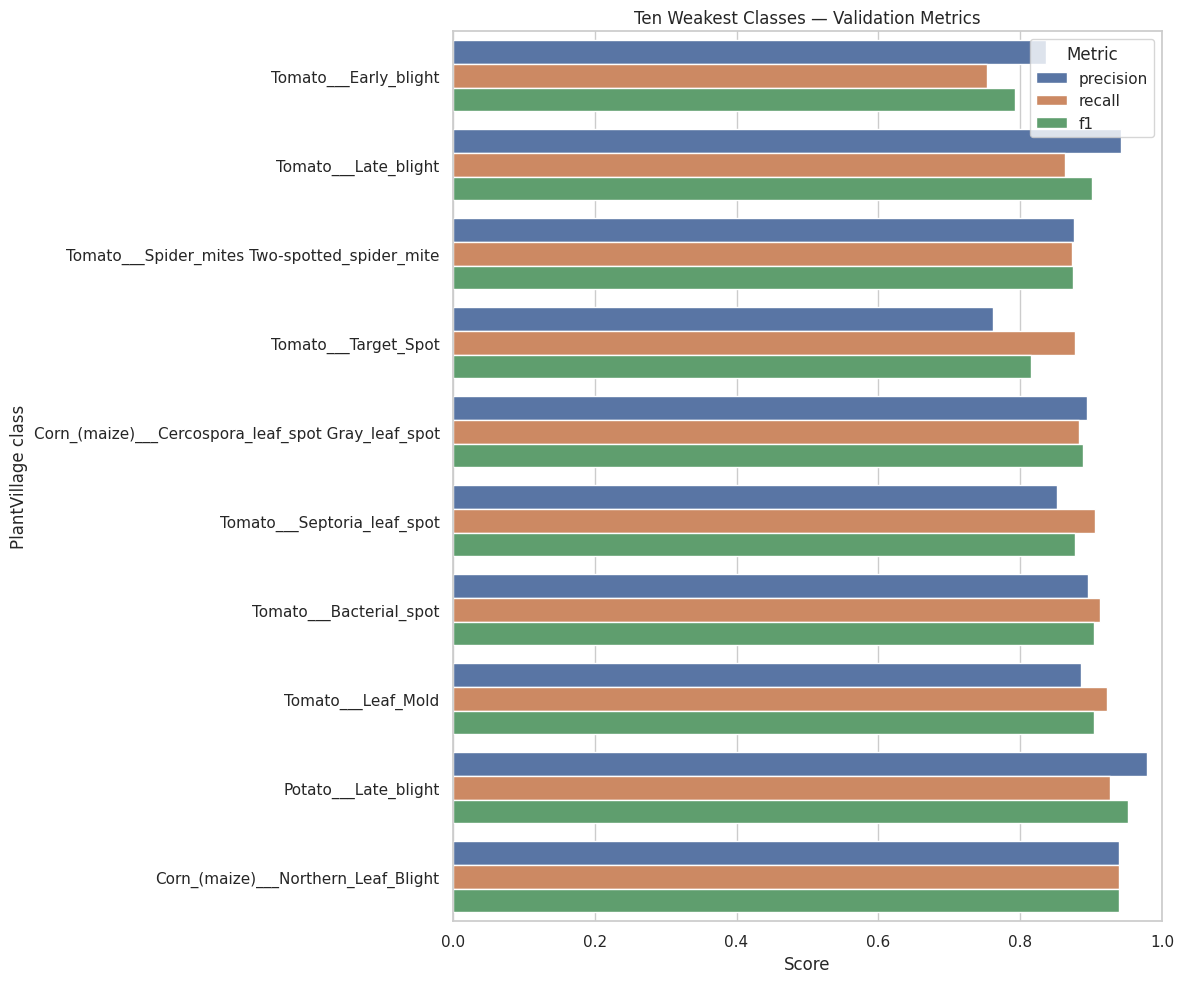

In [17]:
plot_data = weakest_classes.melt(
    id_vars=["class", "support"],
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score"
)
plt.figure(figsize=(12, 10))

sns.barplot(
    data=plot_data,
    y="class",
    x="score",
    hue="metric"
)

plt.xlim(0, 1)
plt.title("Ten Weakest Classes — Validation Metrics")
plt.xlabel("Score")
plt.ylabel("PlantVillage class")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [18]:
CONFUSION_PATH = (
    VALIDATION_EVAL_DIR /
    "confusion_matrix.csv"
)

confusion = pd.read_csv(
    CONFUSION_PATH,
    index_col=0
)

TARGET_CLASS = "Tomato___Early_blight"

assert TARGET_CLASS in confusion.index
assert TARGET_CLASS in confusion.columns

# ---------------------------------------------------------
# 1. Where actual Early-blight images were predicted
# ---------------------------------------------------------

early_predictions = (
    confusion.loc[TARGET_CLASS]
    .sort_values(ascending=False)
    .rename("images")
    .reset_index()
    .rename(columns={"index": "predicted_class"})
)

early_predictions["percentage"] = (
    early_predictions["images"] /
    early_predictions["images"].sum() *
    100
)

print("Actual Early-blight images were predicted as:")
display(early_predictions.head(10))

# ---------------------------------------------------------
# 2. Which classes were falsely predicted as Early blight
# ---------------------------------------------------------

false_early_sources = (
    confusion[TARGET_CLASS]
    .drop(index=TARGET_CLASS)
    .sort_values(ascending=False)
    .rename("images")
    .reset_index()
    .rename(columns={"index": "actual_class"})
)

false_early_sources = false_early_sources[
    false_early_sources["images"] > 0
]

print("\nOther classes incorrectly predicted as Early blight:")
display(false_early_sources.head(10))

# ---------------------------------------------------------
# 3. Key Early-blight counts
# ---------------------------------------------------------

true_positive = int(
    confusion.loc[TARGET_CLASS, TARGET_CLASS]
)

total_actual = int(
    confusion.loc[TARGET_CLASS].sum()
)

total_predicted = int(
    confusion[TARGET_CLASS].sum()
)

false_negative = total_actual - true_positive
false_positive = total_predicted - true_positive

print("\nEarly-blight summary:")
print("Actual images:", total_actual)
print("Correct predictions:", true_positive)
print("Missed Early-blight images:", false_negative)
print("False Early-blight predictions:", false_positive)
print("Recall:", round(true_positive / total_actual, 4))
print("Precision:", round(true_positive / total_predicted, 4))

Actual Early-blight images were predicted as:


,predicted_class,images,percentage
0,Tomato___Early_blight,113,75.333333
1,Tomato___Septoria_leaf_spot,12,8.000000
2,Tomato___Target_Spot,9,6.000000
3,Tomato___Bacterial_spot,8,5.333333
4,Tomato___Late_blight,4,2.666667
5,Tomato___Spider_mites Two-spotted_spider_mite,2,1.333333
6,Potato___Late_blight,1,0.666667
7,Tomato___Tomato_mosaic_virus,1,0.666667
8,Cherry_(including_sour)___Powdery_mildew,0,0.000000
9,Blueberry___healthy,0,0.000000



Other classes incorrectly predicted as Early blight:


,actual\predicted,images
0,Tomato___Late_blight,8
1,Tomato___Bacterial_spot,4
2,Tomato___Septoria_leaf_spot,4
3,Tomato___Tomato_Yellow_Leaf_Curl_Virus,2
4,Potato___Early_blight,1
5,Tomato___Spider_mites Two-spotted_spider_mite,1
6,Tomato___Target_Spot,1
7,Tomato___Leaf_Mold,1



Early-blight summary:
Actual images: 150
Correct predictions: 113
Missed Early-blight images: 37
False Early-blight predictions: 22
Recall: 0.7533
Precision: 0.837


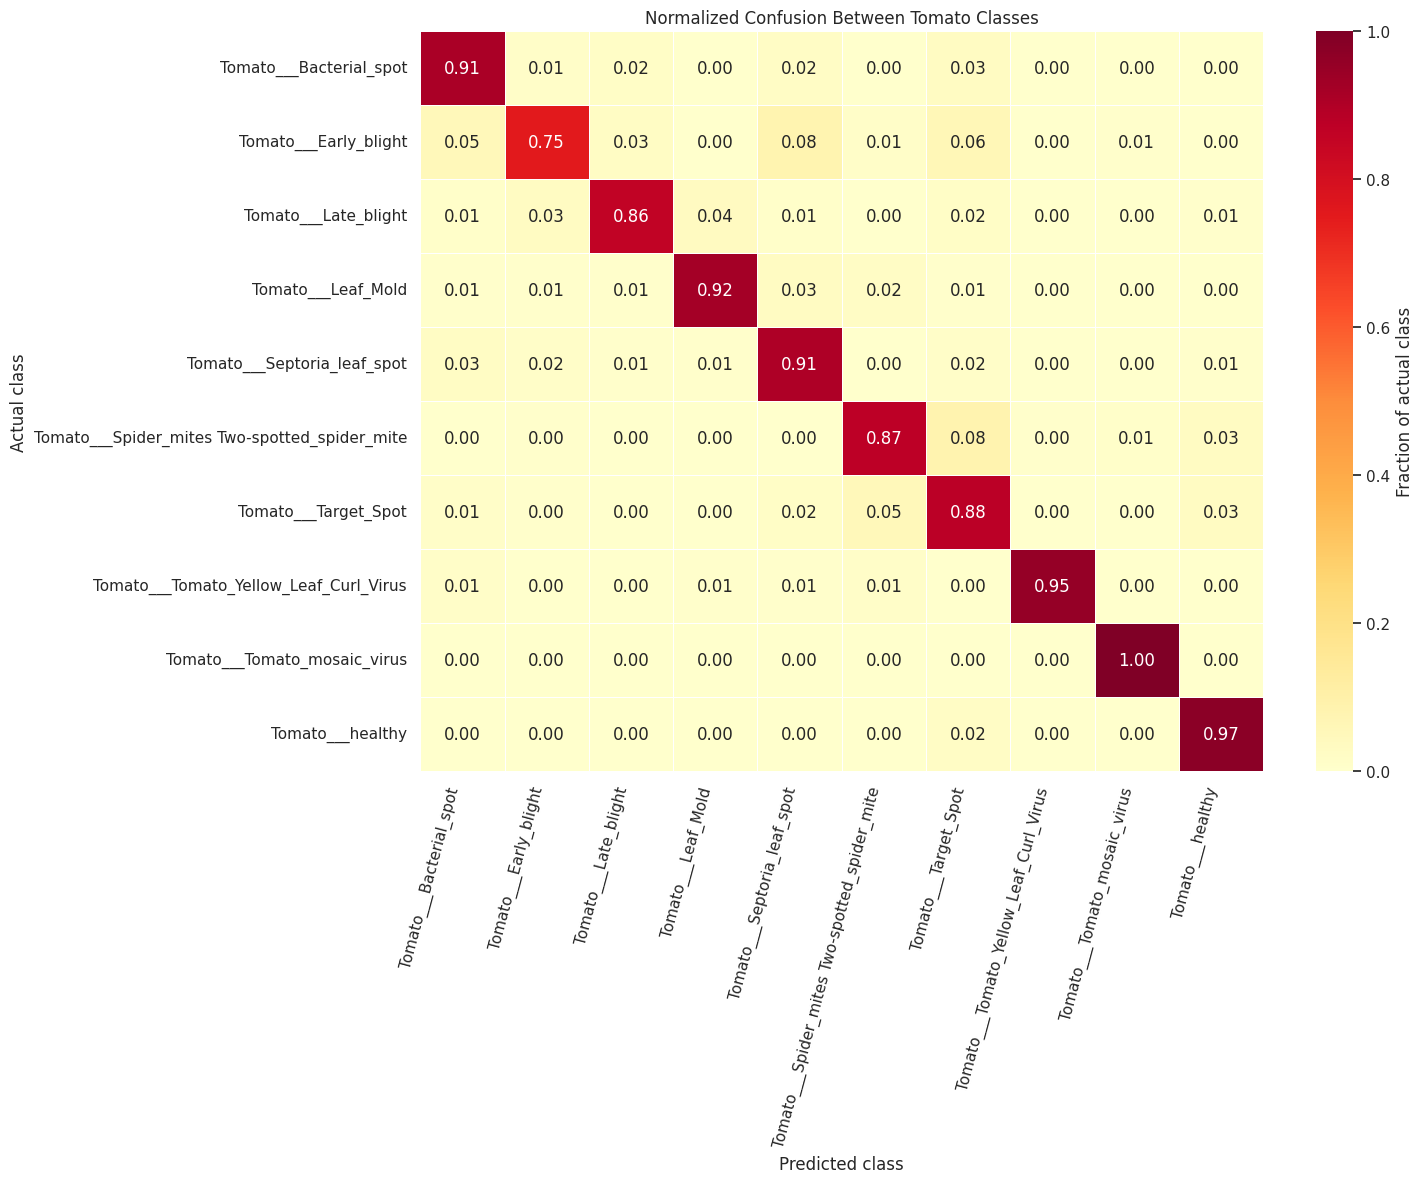

In [19]:
tomato_classes = [
    class_name
    for class_name in confusion.index
    if class_name.startswith("Tomato")
]

tomato_confusion = confusion.loc[
    tomato_classes,
    tomato_classes
]

# Row-normalization: each row represents one actual class
tomato_confusion_normalized = (
    tomato_confusion
    .div(confusion.loc[tomato_classes].sum(axis=1), axis=0)
)

plt.figure(figsize=(15, 12))

sns.heatmap(
    tomato_confusion_normalized,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "Fraction of actual class"}
)

plt.title("Normalized Confusion Between Tomato Classes")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.xticks(rotation=75, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
import json
import shutil
import time
import tensorflow as tf

from agrie_edge.config import load_config
from agrie_edge.data import (
    load_label_contract,
    load_records,
    make_dataset,
    class_weights,
)
from agrie_edge.model import (
    build_classifier,
    compile_classifier,
    enable_fine_tuning,
)

# ---------------------------------------------------------
# 1. Candidate output folder — v1 remains untouched
# ---------------------------------------------------------

CANDIDATE_DIR = (
    WORK_ROOT /
    "training_candidate_v2"
)

CANDIDATE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CANDIDATE_CHECKPOINT = (
    CANDIDATE_DIR /
    "continued_best.weights.h5"
)

# ---------------------------------------------------------
# 2. Reconstruct datasets
# ---------------------------------------------------------

config = load_config(FAST_CONFIG)

labels = load_label_contract(
    MANIFEST_DIR / "labels.json"
)

train_records = load_records(
    MANIFEST_DIR / "manifest.csv",
    PLANTVILLAGE_DIR,
    "train"
)

validation_records = load_records(
    MANIFEST_DIR / "manifest.csv",
    PLANTVILLAGE_DIR,
    "validation"
)

train_dataset = make_dataset(
    train_records,
    config.image_size,
    config.batch_size,
    training=True,
    seed=config.seed,
    augmentation_mode="fast_fine_tune",
)

validation_dataset = make_dataset(
    validation_records,
    config.image_size,
    config.batch_size,
    training=False,
    seed=config.seed,
)

training_class_weights = class_weights(
    train_records,
    len(labels)
)

# Do not apply an Early-blight multiplier yet
print(
    "Early-blight standard class weight:",
    training_class_weights[29]
)

# ---------------------------------------------------------
# 3. Restore the best four-epoch model
# ---------------------------------------------------------

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(config.seed)
tf.keras.mixed_precision.set_global_policy(
    "mixed_float16"
)

candidate_model = build_classifier(
    num_classes=len(labels),
    image_size=config.image_size,
    alpha=config.mobilenet_alpha,
    dropout=config.dropout,
)

candidate_model.load_weights(
    TRAINING_DIR /
    "fine_tune_fast.weights.h5"
)

trainable_layers = enable_fine_tuning(
    candidate_model,
    unfreeze_from=130
)

# Lower than previous 1e-5 learning rate
CONTINUATION_LR = 3e-6

compile_classifier(
    candidate_model,
    learning_rate=CONTINUATION_LR
)

print("Trainable non-BatchNorm layers:", trainable_layers)
print("Continuation learning rate:", CONTINUATION_LR)

before_metrics = candidate_model.evaluate(
    validation_dataset,
    verbose=1,
    return_dict=True,
)

print("\nMetrics before continuation:")
print(before_metrics)

# ---------------------------------------------------------
# 4. Train for a maximum of two additional epochs
# ---------------------------------------------------------

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        CANDIDATE_CHECKPOINT,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=1,
        restore_best_weights=False,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(
        CANDIDATE_DIR /
        "continuation_history.csv"
    ),
]

print("\nStarting two-epoch conservative continuation...")

start_time = time.time()

continuation_history = candidate_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=2,
    class_weight=training_class_weights,
    callbacks=callbacks,
    verbose=2,
)

print(
    "\nContinuation finished in",
    round((time.time() - start_time) / 60, 1),
    "minutes"
)

# ---------------------------------------------------------
# 5. Load best candidate and save separately
# ---------------------------------------------------------

candidate_model.load_weights(
    CANDIDATE_CHECKPOINT
)

after_metrics = candidate_model.evaluate(
    validation_dataset,
    verbose=1,
    return_dict=True,
)

candidate_model.save(
    CANDIDATE_DIR /
    "agrieedge_candidate_v2.keras"
)

candidate_model.save(
    CANDIDATE_DIR /
    "agrieedge_candidate_v2.h5"
)

shutil.copy2(
    MANIFEST_DIR / "labels.json",
    CANDIDATE_DIR / "labels.json"
)

candidate_summary = {
    "sourceModel": "fine_tune_fast.weights.h5",
    "additionalEpochs": len(
        continuation_history.epoch
    ),
    "learningRate": CONTINUATION_LR,
    "unfreezeFrom": 130,
    "trainableNonBatchNormLayers": trainable_layers,
    "beforeMetrics": {
        key: float(value)
        for key, value in before_metrics.items()
    },
    "afterMetrics": {
        key: float(value)
        for key, value in after_metrics.items()
    },
}

(
    CANDIDATE_DIR /
    "candidate_summary.json"
).write_text(
    json.dumps(candidate_summary, indent=2),
    encoding="utf-8"
)

print("\nCandidate v2 metrics:")
print(json.dumps(candidate_summary, indent=2))

print("\nCandidate saved separately at:")
print(CANDIDATE_DIR)
print("\nOriginal v1 model has not been modified.")

Early-blight standard class weight: 1.4284962406015038
Trainable non-BatchNorm layers: 16
Continuation learning rate: 3e-06


I0000 00:00:1787488829.988671     149 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


128/128 ━━━━━━━━━━━━━━━━━━━━ 50s 232ms/step - accuracy: 0.9601 - loss: 0.1246 - top3_accuracy: 0.9956

Metrics before continuation:
{'accuracy': 0.9601227045059204, 'loss': 0.12462899088859558, 'top3_accuracy': 0.9955828189849854}

Starting two-epoch conservative continuation...
Epoch 1/2

Epoch 1: val_loss improved from None to 0.11639, saving model to /kaggle/working/agrieedge_resume/training_candidate_v2/continued_best.weights.h5

Epoch 1: finished saving model to /kaggle/working/agrieedge_resume/training_candidate_v2/continued_best.weights.h5
594/594 - 164s - 276ms/step - accuracy: 0.9614 - loss: 0.1116 - top3_accuracy: 0.9963 - val_accuracy: 0.9647 - val_loss: 0.1164 - val_top3_accuracy: 0.9962
Epoch 2/2

Epoch 2: val_loss improved from 0.11639 to 0.11434, saving model to /kaggle/working/agrieedge_resume/training_candidate_v2/continued_best.weights.h5

Epoch 2: finished saving model to /kaggle/working/agrieedge_resume/training_candidate_v2/continued_best.weights.h5
594/594 - 109s 


Candidate v2 metrics:
{
  "sourceModel": "fine_tune_fast.weights.h5",
  "additionalEpochs": 2,
  "learningRate": 3e-06,
  "unfreezeFrom": 130,
  "trainableNonBatchNormLayers": 16,
  "beforeMetrics": {
    "accuracy": 0.9601227045059204,
    "loss": 0.12462899088859558,
    "top3_accuracy": 0.9955828189849854
  },
  "afterMetrics": {
    "accuracy": 0.9640491008758545,
    "loss": 0.11434173583984375,
    "top3_accuracy": 0.996687114238739
  }
}

Candidate saved separately at:
/kaggle/working/agrieedge_resume/training_candidate_v2

Original v1 model has not been modified.


In [21]:
import subprocess
import sys
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Evaluate candidate v2 on validation data
# ---------------------------------------------------------

CANDIDATE_MODEL = (
    CANDIDATE_DIR /
    "agrieedge_candidate_v2.keras"
)

CANDIDATE_EVAL_DIR = (
    WORK_ROOT /
    "evaluation" /
    "validation_candidate_v2"
)

CANDIDATE_EVAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

candidate_evaluation_command = [
    sys.executable,
    "-u",
    str(EVALUATE_SCRIPT),
    "--dataset-dir",
    str(PLANTVILLAGE_DIR),
    "--manifest-dir",
    str(MANIFEST_DIR),
    "--model",
    str(CANDIDATE_MODEL),
    "--output-dir",
    str(CANDIDATE_EVAL_DIR),
    "--config",
    str(FAST_CONFIG),
    "--split",
    "validation",
]

print("Evaluating candidate v2...")

subprocess.run(
    candidate_evaluation_command,
    check=True
)

# ---------------------------------------------------------
# 2. Load overall metrics
# ---------------------------------------------------------

v1_metrics = json.loads(
    (
        VALIDATION_EVAL_DIR /
        "metrics.json"
    ).read_text()
)

v2_metrics = json.loads(
    (
        CANDIDATE_EVAL_DIR /
        "metrics.json"
    ).read_text()
)

metric_names = [
    "accuracy",
    "balancedAccuracy",
    "macroF1",
    "weightedF1",
    "top3Accuracy",
    "logLoss",
    "expectedCalibrationError10Bins",
    "acceptanceRate",
    "acceptedAccuracy",
    "uncertainCount",
]

overall_comparison = pd.DataFrame([
    {
        "metric": metric,
        "v1": v1_metrics[metric],
        "v2": v2_metrics[metric],
        "change": (
            v2_metrics[metric] -
            v1_metrics[metric]
        ),
    }
    for metric in metric_names
])

print("\nOverall model comparison:")
display(overall_comparison)

# ---------------------------------------------------------
# 3. Compare per-class reports
# ---------------------------------------------------------

v1_report = json.loads(
    (
        VALIDATION_EVAL_DIR /
        "classification_report.json"
    ).read_text()
)

v2_report = json.loads(
    (
        CANDIDATE_EVAL_DIR /
        "classification_report.json"
    ).read_text()
)

labels = json.loads(
    (
        TRAINING_DIR /
        "labels.json"
    ).read_text()
)

class_comparison_rows = []

for label in labels:
    class_name = label["datasetLabel"]

    class_comparison_rows.append({
        "class": class_name,
        "support": int(
            v1_report[class_name]["support"]
        ),
        "precision_v1": v1_report[class_name]["precision"],
        "precision_v2": v2_report[class_name]["precision"],
        "precision_change": (
            v2_report[class_name]["precision"] -
            v1_report[class_name]["precision"]
        ),
        "recall_v1": v1_report[class_name]["recall"],
        "recall_v2": v2_report[class_name]["recall"],
        "recall_change": (
            v2_report[class_name]["recall"] -
            v1_report[class_name]["recall"]
        ),
        "f1_v1": v1_report[class_name]["f1-score"],
        "f1_v2": v2_report[class_name]["f1-score"],
        "f1_change": (
            v2_report[class_name]["f1-score"] -
            v1_report[class_name]["f1-score"]
        ),
    })

class_comparison = pd.DataFrame(
    class_comparison_rows
)

# ---------------------------------------------------------
# 4. Focus on confused tomato diseases
# ---------------------------------------------------------

focus_classes = [
    "Tomato___Early_blight",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Target_Spot",
    "Tomato___Bacterial_spot",
    "Tomato___Late_blight",
]

tomato_comparison = (
    class_comparison[
        class_comparison["class"].isin(
            focus_classes
        )
    ]
    .sort_values("recall_v1")
)

print("\nImportant tomato-disease comparison:")
display(tomato_comparison)

print("\nLargest recall improvements:")
display(
    class_comparison
    .sort_values("recall_change", ascending=False)
    .head(8)
)

print("\nLargest recall reductions:")
display(
    class_comparison
    .sort_values("recall_change")
    .head(8)
)

Evaluating candidate v2...


I0000 00:00:1787489316.577662     721 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13187 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1787489332.593250     750 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


128/128 ━━━━━━━━━━━━━━━━━━━━ 50s 233ms/step
{
  "split": "validation",
  "images": 8150,
  "accuracy": 0.9640490797546012,
  "balancedAccuracy": 0.9631753980093112,
  "macroF1": 0.9598163815116423,
  "weightedF1": 0.9641364976008174,
  "top3Accuracy": 0.9966871165644172,
  "logLoss": 0.11434174892977814,
  "expectedCalibrationError10Bins": 0.002972717877545973,
  "acceptanceRate": 0.9760736196319019,
  "acceptedAccuracy": 0.97561282212445,
  "uncertainCount": 195,
  "thresholds": {
    "minimumConfidence": 0.6,
    "minimumTop1Top2Margin": 0.1
  }
}

Overall model comparison:


,metric,v1,v2,change
0,accuracy,0.960123,0.964049,0.003926
1,balancedAccuracy,0.959712,0.963175,0.003464
2,macroF1,0.954408,0.959816,0.005408
3,weightedF1,0.960355,0.964136,0.003781
4,top3Accuracy,0.995583,0.996687,0.001104
5,logLoss,0.124629,0.114342,-0.010287
6,expectedCalibrationError10Bins,0.004017,0.002973,-0.001044
7,acceptanceRate,0.970184,0.976074,0.005890
8,acceptedAccuracy,0.974832,0.975613,0.000780
9,uncertainCount,243.000000,195.000000,-48.000000



Important tomato-disease comparison:


,class,support,precision_v1,precision_v2,precision_change,recall_v1,recall_v2,recall_change,f1_v1,f1_v2,f1_change
29,Tomato___Early_blight,150,0.837037,0.840909,0.003872,0.753333,0.740000,-0.013333,0.792982,0.787234,-0.005748
30,Tomato___Late_blight,285,0.942529,0.938931,-0.003597,0.863158,0.863158,0.000000,0.901099,0.899452,-0.001647
34,Tomato___Target_Spot,211,0.761317,0.837209,0.075892,0.876777,0.853081,-0.023697,0.814978,0.845070,0.030092
32,Tomato___Septoria_leaf_spot,266,0.851590,0.826667,-0.024923,0.906015,0.932331,0.026316,0.877960,0.876325,-0.001635
28,Tomato___Bacterial_spot,319,0.895385,0.921875,0.026490,0.912226,0.924765,0.012539,0.903727,0.923318,0.019591



Largest recall improvements:


,class,support,precision_v1,precision_v2,precision_change,recall_v1,recall_v2,recall_change,f1_v1,f1_v2,f1_change
33,Tomato___Spider_mites Two-spotted_spider_mite,252,0.876494,0.852399,-0.024095,0.873016,0.916667,0.043651,0.874751,0.883365,0.008614
21,Potato___Late_blight,150,0.978873,0.947368,-0.031505,0.926667,0.960000,0.033333,0.952055,0.953642,0.001588
32,Tomato___Septoria_leaf_spot,266,0.851590,0.826667,-0.024923,0.906015,0.932331,0.026316,0.877960,0.876325,-0.001635
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,77,0.894737,0.864198,-0.030539,0.883117,0.909091,0.025974,0.888889,0.886076,-0.002813
16,Peach___Bacterial_spot,345,0.997024,0.997076,0.000052,0.971014,0.988406,0.017391,0.983847,0.992722,0.008875
27,Strawberry___healthy,69,0.985507,0.985714,0.000207,0.985507,1.000000,0.014493,0.985507,0.992806,0.007299
12,Grape___Esca_(Black_Measles),208,0.980392,0.980676,0.000284,0.961538,0.975962,0.014423,0.970874,0.978313,0.007439
31,Tomato___Leaf_Mold,143,0.885906,0.893333,0.007427,0.923077,0.937063,0.013986,0.904110,0.914676,0.010566



Largest recall reductions:


,class,support,precision_v1,precision_v2,precision_change,recall_v1,recall_v2,recall_change,f1_v1,f1_v2,f1_change
34,Tomato___Target_Spot,211,0.761317,0.837209,0.075892,0.876777,0.853081,-0.023697,0.814978,0.845070,0.030092
9,Corn_(maize)___Northern_Leaf_Blight,148,0.939189,0.944444,0.005255,0.939189,0.918919,-0.020270,0.939189,0.931507,-0.007682
36,Tomato___Tomato_mosaic_virus,56,0.918033,0.948276,0.030243,1.000000,0.982143,-0.017857,0.957265,0.964912,0.007647
19,"Pepper,_bell___healthy",222,0.969163,0.990868,0.021705,0.990991,0.977477,-0.013514,0.979955,0.984127,0.004172
29,Tomato___Early_blight,150,0.837037,0.840909,0.003872,0.753333,0.740000,-0.013333,0.792982,0.787234,-0.005748
20,Potato___Early_blight,150,0.993197,1.000000,0.006803,0.973333,0.966667,-0.006667,0.983165,0.983051,-0.000114
37,Tomato___healthy,238,0.928000,0.958506,0.030506,0.974790,0.970588,-0.004202,0.950820,0.964509,0.013690
3,Apple___healthy,246,0.995902,0.995885,-0.000017,0.987805,0.983740,-0.004065,0.991837,0.989775,-0.002062


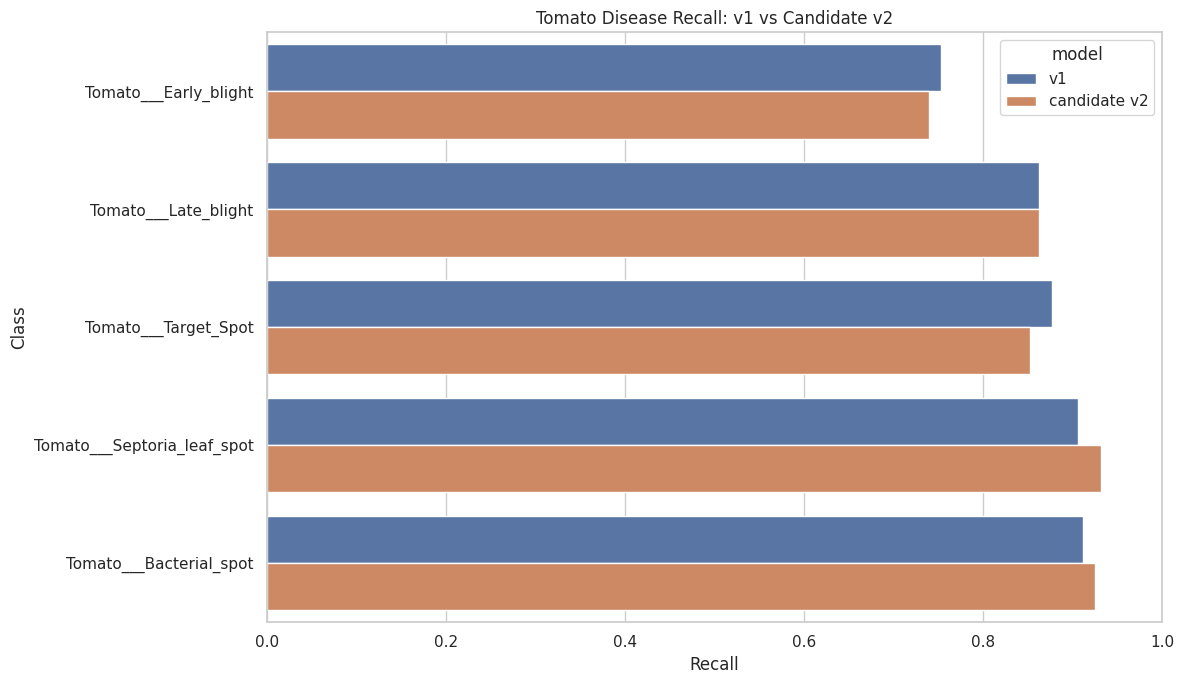

In [22]:
recall_plot = tomato_comparison[
    ["class", "recall_v1", "recall_v2"]
].melt(
    id_vars="class",
    var_name="model",
    value_name="recall"
)

recall_plot["model"] = recall_plot["model"].map({
    "recall_v1": "v1",
    "recall_v2": "candidate v2",
})

plt.figure(figsize=(12, 7))

sns.barplot(
    data=recall_plot,
    y="class",
    x="recall",
    hue="model"
)

plt.xlim(0, 1)
plt.title("Tomato Disease Recall: v1 vs Candidate v2")
plt.xlabel("Recall")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

In [23]:
from agrie_edge.config import load_config
from agrie_edge.data import (
    load_records,
    make_dataset,
    load_label_contract,
)

config = load_config(FAST_CONFIG)

labels = load_label_contract(
    MANIFEST_DIR / "labels.json"
)

label_names = [
    item["datasetLabel"]
    for item in labels
]

EARLY_CLASS = "Tomato___Early_blight"

early_id = next(
    item["id"]
    for item in labels
    if item["datasetLabel"] == EARLY_CLASS
)

validation_records = load_records(
    MANIFEST_DIR / "manifest.csv",
    PLANTVILLAGE_DIR,
    "validation"
)

validation_dataset = make_dataset(
    validation_records,
    config.image_size,
    config.batch_size,
    training=False,
    seed=config.seed,
)

model_v2 = tf.keras.models.load_model(
    CANDIDATE_MODEL,
    compile=False
)

print("Generating candidate-v2 validation probabilities...")

probabilities = np.asarray(
    model_v2.predict(
        validation_dataset,
        verbose=1
    )
)

true_labels = np.asarray(
    [label for _, label in validation_records],
    dtype=np.int64
)

predicted_labels = probabilities.argmax(axis=1)

# Ordered class indices from most to least probable
ranking = np.argsort(
    -probabilities,
    axis=1
)

# Rank of the actual class: 1 means top-1
true_ranks = (
    np.argmax(
        ranking == true_labels[:, None],
        axis=1
    ) + 1
)

confidence = probabilities.max(axis=1)

sorted_probabilities = np.sort(
    probabilities,
    axis=1
)

margin = (
    sorted_probabilities[:, -1] -
    sorted_probabilities[:, -2]
)

accepted = (
    (confidence >= 0.60) &
    (margin >= 0.10)
)

early_mask = true_labels == early_id
early_ranks = true_ranks[early_mask]
early_accepted = accepted[early_mask]
early_confidence = confidence[early_mask]

top1_recall = float(
    np.mean(early_ranks <= 1)
)

top2_recall = float(
    np.mean(early_ranks <= 2)
)

top3_recall = float(
    np.mean(early_ranks <= 3)
)

top1_missed = early_ranks > 1

rescued_by_top3 = int(
    np.sum(
        top1_missed &
        (early_ranks <= 3)
    )
)

missed_outside_top3 = int(
    np.sum(early_ranks > 3)
)

accepted_wrong = int(
    np.sum(
        top1_missed &
        early_accepted
    )
)

uncertain_wrong = int(
    np.sum(
        top1_missed &
        ~early_accepted
    )
)

topk_summary = {
    "class": EARLY_CLASS,
    "support": int(early_mask.sum()),
    "top1Recall": top1_recall,
    "top2Recall": top2_recall,
    "top3Recall": top3_recall,
    "top1Missed": int(top1_missed.sum()),
    "rescuedByTop3": rescued_by_top3,
    "outsideTop3": missed_outside_top3,
    "wrongButAccepted": accepted_wrong,
    "wrongAndMarkedUncertain": uncertain_wrong,
    "meanConfidence": float(
        early_confidence.mean()
    ),
}

print("\nEarly-blight top-k analysis:")
print(json.dumps(topk_summary, indent=2))

(
    CANDIDATE_EVAL_DIR /
    "early_blight_topk_analysis.json"
).write_text(
    json.dumps(topk_summary, indent=2),
    encoding="utf-8"
)

Generating candidate-v2 validation probabilities...
128/128 ━━━━━━━━━━━━━━━━━━━━ 33s 168ms/step

Early-blight top-k analysis:
{
  "class": "Tomato___Early_blight",
  "support": 150,
  "top1Recall": 0.74,
  "top2Recall": 0.9133333333333333,
  "top3Recall": 0.9733333333333334,
  "top1Missed": 39,
  "rescuedByTop3": 35,
  "outsideTop3": 4,
  "wrongButAccepted": 27,
  "wrongAndMarkedUncertain": 12,
  "meanConfidence": 0.8251643776893616
}


312

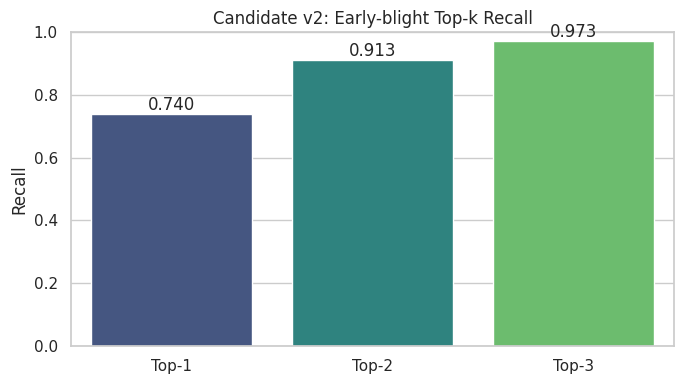

In [25]:
topk_plot = pd.DataFrame({
    "prediction depth": [
        "Top-1",
        "Top-2",
        "Top-3"
    ],
    "recall": [
        top1_recall,
        top2_recall,
        top3_recall
    ]
})

sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=topk_plot,
    x="prediction depth",
    y="recall",
    hue="prediction depth",
    palette="viridis",
    legend=False
)

ax.set_ylim(0, 1)
ax.set_title(
    "Candidate v2: Early-blight Top-k Recall"
)
ax.set_xlabel("")
ax.set_ylabel("Recall")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f"
    )

plt.tight_layout()
plt.show()

In [26]:
# ---------------------------------------------------------
# 1. Create immutable-style locked model folder
# ---------------------------------------------------------

LOCKED_MODEL_DIR = (
    WORK_ROOT /
    "locked_model_v2"
)

LOCKED_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOCKED_KERAS_MODEL = (
    LOCKED_MODEL_DIR /
    "agrieedge_mobilenetv2_v2.keras"
)

LOCKED_H5_MODEL = (
    LOCKED_MODEL_DIR /
    "agrieedge_mobilenetv2_v2.h5"
)

shutil.copy2(
    CANDIDATE_DIR /
    "agrieedge_candidate_v2.keras",
    LOCKED_KERAS_MODEL
)

shutil.copy2(
    CANDIDATE_DIR /
    "agrieedge_candidate_v2.h5",
    LOCKED_H5_MODEL
)

shutil.copy2(
    CANDIDATE_DIR /
    "labels.json",
    LOCKED_MODEL_DIR /
    "labels.json"
)

shutil.copy2(
    TRAINING_DIR /
    "training_config.json",
    LOCKED_MODEL_DIR /
    "training_config.json"
)

shutil.copy2(
    CANDIDATE_DIR /
    "candidate_summary.json",
    LOCKED_MODEL_DIR /
    "candidate_summary.json"
)

shutil.copy2(
    CANDIDATE_EVAL_DIR /
    "metrics.json",
    LOCKED_MODEL_DIR /
    "validation_metrics.json"
)

shutil.copy2(
    CANDIDATE_EVAL_DIR /
    "classification_report.json",
    LOCKED_MODEL_DIR /
    "validation_classification_report.json"
)

shutil.copy2(
    CANDIDATE_EVAL_DIR /
    "confusion_matrix.csv",
    LOCKED_MODEL_DIR /
    "validation_confusion_matrix.csv"
)

shutil.copy2(
    CANDIDATE_EVAL_DIR /
    "early_blight_topk_analysis.json",
    LOCKED_MODEL_DIR /
    "early_blight_topk_analysis.json"
)

selection_record = {
    "modelVersion": "mobilenetv2-v2",
    "status": "locked",
    "selectedFrom": "training_candidate_v2",
    "selectionSplit": "validation",
    "validationMetrics": v2_metrics,
    "earlyBlightTopK": topk_summary,
    "decision": (
        "Selected for higher balanced accuracy, macro F1, "
        "calibration, log-loss and global top-3 accuracy."
    ),
    "knownLimitation": (
        "Tomato Early blight has 0.74 top-1 validation recall, "
        "but 0.9733 top-3 validation recall."
    ),
    "productPolicy": (
        "Display top-3 differential diagnoses and request "
        "another image or expert verification for similar "
        "tomato lesion classes."
    ),
}

(
    LOCKED_MODEL_DIR /
    "model_selection.json"
).write_text(
    json.dumps(
        selection_record,
        indent=2
    ),
    encoding="utf-8"
)

print("Locked model:", LOCKED_KERAS_MODEL)
print("Model-selection record saved.")

# ---------------------------------------------------------
# 2. Evaluate the untouched test split
# ---------------------------------------------------------

TEST_EVAL_DIR = (
    WORK_ROOT /
    "evaluation" /
    "test_locked_v2"
)

TEST_EVAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

test_evaluation_command = [
    sys.executable,
    "-u",
    str(EVALUATE_SCRIPT),
    "--dataset-dir",
    str(PLANTVILLAGE_DIR),
    "--manifest-dir",
    str(MANIFEST_DIR),
    "--model",
    str(LOCKED_KERAS_MODEL),
    "--output-dir",
    str(TEST_EVAL_DIR),
    "--config",
    str(FAST_CONFIG),
    "--split",
    "test",
]

print("\nRunning the one-time final test evaluation...")

subprocess.run(
    test_evaluation_command,
    check=True
)

test_metrics = json.loads(
    (
        TEST_EVAL_DIR /
        "metrics.json"
    ).read_text()
)

print("\nFinal untouched-test metrics:")
print(
    json.dumps(
        test_metrics,
        indent=2
    )
)

(
    LOCKED_MODEL_DIR /
    "test_metrics.json"
).write_text(
    json.dumps(
        test_metrics,
        indent=2
    ),
    encoding="utf-8"
)

print("\nTest metrics copied into locked-model folder.")
print("The model is now frozen—do not train based on test results.")

Locked model: /kaggle/working/agrieedge_resume/locked_model_v2/agrieedge_mobilenetv2_v2.keras
Model-selection record saved.

Running the one-time final test evaluation...


I0000 00:00:1787490053.736014     864 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13185 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1787490070.230455     893 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


128/128 ━━━━━━━━━━━━━━━━━━━━ 62s 325ms/step
{
  "split": "test",
  "images": 8136,
  "accuracy": 0.9659537856440511,
  "balancedAccuracy": 0.961460728340752,
  "macroF1": 0.9578964428581238,
  "weightedF1": 0.9659885320798495,
  "top3Accuracy": 0.997173058013766,
  "logLoss": 0.10766254998516948,
  "expectedCalibrationError10Bins": 0.0033505511568125137,
  "acceptanceRate": 0.9749262536873157,
  "acceptedAccuracy": 0.9776853252647504,
  "uncertainCount": 204,
  "thresholds": {
    "minimumConfidence": 0.6,
    "minimumTop1Top2Margin": 0.1
  }
}

Final untouched-test metrics:
{
  "split": "test",
  "images": 8136,
  "accuracy": 0.9659537856440511,
  "balancedAccuracy": 0.961460728340752,
  "macroF1": 0.9578964428581238,
  "weightedF1": 0.9659885320798495,
  "top3Accuracy": 0.997173058013766,
  "logLoss": 0.10766254998516948,
  "expectedCalibrationError10Bins": 0.0033505511568125137,
  "acceptanceRate": 0.9749262536873157,
  "acceptedAccuracy": 0.9776853252647504,
  "uncertainCount": 204

In [27]:
import hashlib
import os
from IPython.display import FileLink, display

# ---------------------------------------------------------
# 1. Copy final test artifacts into locked-model folder
# ---------------------------------------------------------

test_artifacts = {
    "classification_report.json":
        "test_classification_report.json",
    "confusion_matrix.csv":
        "test_confusion_matrix.csv",
    "metrics.json":
        "test_metrics.json",
}

for source_name, destination_name in test_artifacts.items():
    source = TEST_EVAL_DIR / source_name
    destination = LOCKED_MODEL_DIR / destination_name

    assert source.is_file(), f"Missing: {source}"
    shutil.copy2(source, destination)

# ---------------------------------------------------------
# 2. Create final model summary
# ---------------------------------------------------------

validation_metrics = json.loads(
    (
        CANDIDATE_EVAL_DIR /
        "metrics.json"
    ).read_text()
)

final_test_metrics = json.loads(
    (
        TEST_EVAL_DIR /
        "metrics.json"
    ).read_text()
)

early_topk = json.loads(
    (
        CANDIDATE_EVAL_DIR /
        "early_blight_topk_analysis.json"
    ).read_text()
)

def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as stream:
        for block in iter(
            lambda: stream.read(1024 * 1024),
            b""
        ):
            digest.update(block)

    return digest.hexdigest()

final_summary = {
    "modelVersion": "mobilenetv2-v2",
    "status": "locked",
    "architecture": "MobileNetV2",
    "classes": 38,
    "inputShape": [1, 224, 224, 3],
    "inputDtype": "float32",
    "inputPixelRange": [0, 255],
    "normalization": (
        "Embedded Rescaling("
        "scale=1/127.5, offset=-1)"
    ),
    "dataset": {
        "sourceImages": 54305,
        "duplicatesRemoved": 21,
        "usableImages": 54284,
        "train": 37998,
        "validation": 8150,
        "test": 8136,
    },
    "validationMetrics": validation_metrics,
    "testMetrics": final_test_metrics,
    "earlyBlightValidationTopK": early_topk,
    "knownLimitations": [
        (
            "PlantVillage mainly contains controlled-"
            "condition leaf photographs."
        ),
        (
            "Tomato Early blight top-1 validation "
            "recall is 0.74."
        ),
        (
            "The UI must show top-3 alternatives and "
            "support uncertain/retake-photo states."
        ),
    ],
    "modelFiles": {
        LOCKED_KERAS_MODEL.name: {
            "bytes": LOCKED_KERAS_MODEL.stat().st_size,
            "sha256": sha256_file(
                LOCKED_KERAS_MODEL
            ),
        },
        LOCKED_H5_MODEL.name: {
            "bytes": LOCKED_H5_MODEL.stat().st_size,
            "sha256": sha256_file(
                LOCKED_H5_MODEL
            ),
        },
    },
}

(
    LOCKED_MODEL_DIR /
    "final_release_summary.json"
).write_text(
    json.dumps(
        final_summary,
        indent=2
    ),
    encoding="utf-8"
)

print("Final release summary created.")

# ---------------------------------------------------------
# 3. Archive the entire reproducible ML workspace
# ---------------------------------------------------------

FINAL_ML_ZIP = Path(
    shutil.make_archive(
        "/kaggle/working/AgriEdge-ML-Locked-v2",
        "zip",
        root_dir=WORK_ROOT
    )
)

print("\nArchive:", FINAL_ML_ZIP)
print(
    "Archive size:",
    round(
        FINAL_ML_ZIP.stat().st_size /
        1024**2,
        2
    ),
    "MB"
)

# ---------------------------------------------------------
# 4. Create direct download link
# ---------------------------------------------------------

os.chdir("/kaggle/working")

print("\nClick below to download:")
display(
    FileLink(
        FINAL_ML_ZIP.name
    )
)

Final release summary created.

Archive: /kaggle/working/AgriEdge-ML-Locked-v2.zip
Archive size: 242.56 MB

Click below to download:


/kaggle/working/AgriEdge-ML-Locked-v2.zip

In [31]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

print("Current notebook Python:", sys.executable)

# Install only TensorFlow.js converter.
# --no-deps prevents TensorFlow/Keras/Numpy from being changed.
installation = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-deps",
        "--upgrade",
        "tensorflowjs==4.22.0",
    ],
    text=True,
    capture_output=True,
)

if installation.stdout:
    print(installation.stdout)

if installation.returncode != 0:
    print("Installation error:")
    print(installation.stderr[-5000:])

assert installation.returncode == 0, "tensorflowjs installation failed."

# Locate the converter executable
candidates = [
    shutil.which("tensorflowjs_converter"),
    str(Path(sys.executable).parent / "tensorflowjs_converter"),
    "/usr/local/bin/tensorflowjs_converter",
    "/opt/conda/bin/tensorflowjs_converter",
    "/root/.local/bin/tensorflowjs_converter",
]

TFJS_CONVERTER = next(
    (Path(path) for path in candidates if path and Path(path).exists()),
    None,
)

print("Converter path:", TFJS_CONVERTER)
assert TFJS_CONVERTER is not None, "Converter executable was not located."

# Check converter without modifying the completed model
environment = os.environ.copy()
environment["TF_USE_LEGACY_KERAS"] = "1"

preflight = subprocess.run(
    [str(TFJS_CONVERTER), "--help"],
    env=environment,
    text=True,
    capture_output=True,
)

print("Converter return code:", preflight.returncode)

if preflight.returncode == 0:
    print("TensorFlow.js converter preflight passed!")
    print("Training model remains unchanged.")
else:
    print("\nConverter preflight error:")
    print(preflight.stderr[-5000:])

Current notebook Python: /usr/bin/python3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.8 MB/s eta 0:00:00

Converter path: /usr/local/bin/tensorflowjs_converter
Converter return code: 0
TensorFlow.js converter preflight passed!
Training model remains unchanged.


In [32]:
from pathlib import Path
from IPython.display import FileLink, display
import json
import os
import shutil
import subprocess
import sys

WORK_ROOT = Path("/kaggle/working/agrieedge_resume")

LOCKED_MODEL = (
    WORK_ROOT
    / "locked_model_v2"
    / "agrieedge_mobilenetv2_v2.h5"
)

LABELS_PATH = (
    WORK_ROOT
    / "locked_model_v2"
    / "labels.json"
)

EXPORT_SCRIPT = (
    WORK_ROOT
    / "AgriEdge"
    / "ml"
    / "scripts"
    / "export_tfjs.py"
)

CONFIG_PATH = (
    WORK_ROOT
    / "AgriEdge"
    / "ml"
    / "configs"
    / "colab-fast-resume.json"
)

OUTPUT_DIR = (
    WORK_ROOT
    / "tfjs_release"
    / "agrieedge-v2"
)

# Find the converter that passed preflight
converter_candidates = [
    shutil.which("tensorflowjs_converter"),
    str(Path(sys.executable).parent / "tensorflowjs_converter"),
    "/usr/local/bin/tensorflowjs_converter",
    "/opt/conda/bin/tensorflowjs_converter",
    "/root/.local/bin/tensorflowjs_converter",
]

TFJS_CONVERTER = next(
    (
        Path(path)
        for path in converter_candidates
        if path and Path(path).exists()
    ),
    None,
)

assert TFJS_CONVERTER is not None, "TensorFlow.js converter is missing."

# Verify source files
for path in [
    LOCKED_MODEL,
    LABELS_PATH,
    EXPORT_SCRIPT,
    CONFIG_PATH,
]:
    assert path.exists(), f"Required file missing: {path}"

print("Starting TensorFlow.js uint8-weight export...")
print("Source model:", LOCKED_MODEL)
print("Output folder:", OUTPUT_DIR)
print("Converter:", TFJS_CONVERTER)

environment = os.environ.copy()
environment["PATH"] = (
    f"{TFJS_CONVERTER.parent}:"
    + environment.get("PATH", "")
)
environment["TF_USE_LEGACY_KERAS"] = "1"
environment["TF_CPP_MIN_LOG_LEVEL"] = "2"
environment["CUDA_VISIBLE_DEVICES"] = "-1"  # Conversion uses CPU

conversion = subprocess.run(
    [
        sys.executable,
        str(EXPORT_SCRIPT),
        "--model",
        str(LOCKED_MODEL),
        "--labels",
        str(LABELS_PATH),
        "--config",
        str(CONFIG_PATH),
        "--output-dir",
        str(OUTPUT_DIR),
        "--model-version",
        "2.0.0",
        "--overwrite",
    ],
    env=environment,
    text=True,
    capture_output=True,
)

print("\nConverter output:")
print(conversion.stdout)

if conversion.returncode != 0:
    print("Converter error:")
    print(conversion.stderr[-6000:])

assert conversion.returncode == 0, "TensorFlow.js conversion failed."

# Read the automatically generated verification manifest
MANIFEST_PATH = OUTPUT_DIR / "artifact_manifest.json"
MODEL_JSON_PATH = OUTPUT_DIR / "model.json"
METADATA_PATH = OUTPUT_DIR / "metadata.json"

assert MODEL_JSON_PATH.exists(), "model.json was not created."
assert MANIFEST_PATH.exists(), "Artifact manifest was not created."
assert METADATA_PATH.exists(), "metadata.json was not created."

manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))

print("\nPost-training quantization verification:")
print("Bundle size:", manifest["totalMegabytes"], "MB")
print("Quantized weight tensors:", manifest["quantizedWeights"])
print("Number of release files:", len(manifest["files"]))

assert manifest["quantizedWeights"] > 0
assert manifest["totalBytes"] < 10_000_000

print("\nFiles generated:")
for file_info in manifest["files"]:
    print(
        f"- {file_info['name']}: "
        f"{file_info['bytes'] / 1_000_000:.3f} MB"
    )

# Create final downloadable TF.js package
TFJS_ZIP_BASE = Path(
    "/kaggle/working/AgriEdge-TFJS-v2-uint8"
)

TFJS_ZIP = Path(
    shutil.make_archive(
        str(TFJS_ZIP_BASE),
        "zip",
        root_dir=OUTPUT_DIR,
    )
)

print("\nTF.js quantized release created successfully!")
print("ZIP:", TFJS_ZIP)
print(
    "ZIP size:",
    round(TFJS_ZIP.stat().st_size / 1_000_000, 3),
    "MB",
)

display(FileLink(str(TFJS_ZIP)))

Starting TensorFlow.js uint8-weight export...
Source model: /kaggle/working/agrieedge_resume/locked_model_v2/agrieedge_mobilenetv2_v2.h5
Output folder: /kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2
Converter: /usr/local/bin/tensorflowjs_converter

Converter output:
failed to lookup keras version from the file,
    this is likely a weight only file
Verified TF.js model: 2.510 MB in /kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2


Post-training quantization verification:
Bundle size: 2.51 MB
Quantized weight tensors: 262
Number of release files: 5

Files generated:
- group1-shard1of2.bin: 2.097 MB
- group1-shard2of2.bin: 0.210 MB
- labels.json: 0.008 MB
- metadata.json: 0.001 MB
- model.json: 0.194 MB

TF.js quantized release created successfully!
ZIP: /kaggle/working/AgriEdge-TFJS-v2-uint8.zip
ZIP size: 1.852 MB


/kaggle/working/AgriEdge-TFJS-v2-uint8.zip

In [33]:
from pathlib import Path
from IPython.display import FileLink, display
import os

ZIP_PATH = Path(
    "/kaggle/working/AgriEdge-TFJS-v2-uint8.zip"
)

assert ZIP_PATH.exists(), "TF.js ZIP file is missing."
assert ZIP_PATH.stat().st_size > 0, "TF.js ZIP is empty."

print("File verified:", ZIP_PATH.name)
print(
    "Size:",
    round(ZIP_PATH.stat().st_size / 1_000_000, 3),
    "MB",
)

# FileLink must be relative to /kaggle/working
os.chdir("/kaggle/working")

print("\nClick the relative link below:")
display(FileLink(ZIP_PATH.name))

File verified: AgriEdge-TFJS-v2-uint8.zip
Size: 1.852 MB

Click the relative link below:


/kaggle/working/AgriEdge-TFJS-v2-uint8.zip

In [34]:
from pathlib import Path
import subprocess
import sys
import json

WORK_ROOT = Path("/kaggle/working/agrieedge_resume")
PROJECT_ROOT = WORK_ROOT / "AgriEdge"

SCRIPT = PROJECT_ROOT / "ml/scripts/create_golden_set.py"
MANIFEST_DIR = WORK_ROOT / "dataset"
LOCKED_MODEL = (
    WORK_ROOT
    / "locked_model_v2"
    / "agrieedge_mobilenetv2_v2.h5"
)
CONFIG_PATH = PROJECT_ROOT / "ml/configs/colab-fast-resume.json"
GOLDEN_DIR = WORK_ROOT / "golden_parity_v2"

# Exact path used during training
DATASET_DIR = Path(
    "/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage"
)

# Fallback if Kaggle mounted it under a different path
if not DATASET_DIR.exists():
    candidates = [
        path
        for path in Path("/kaggle/input").rglob("PlantVillage")
        if (path / "train").is_dir() and (path / "val").is_dir()
    ]

    print("PlantVillage candidates:", candidates)

    assert len(candidates) == 1, (
        f"Expected exactly one PlantVillage directory, "
        f"but found {len(candidates)}"
    )

    DATASET_DIR = candidates[0]

required_files = {
    "Golden-set script": SCRIPT,
    "Manifest": MANIFEST_DIR / "manifest.csv",
    "Labels": MANIFEST_DIR / "labels.json",
    "Locked model": LOCKED_MODEL,
    "Configuration": CONFIG_PATH,
}

print("Required-file check:")
for name, file_path in required_files.items():
    print(f"{name}: {file_path.exists()} -> {file_path}")
    assert file_path.exists(), f"Missing: {file_path}"

print("\nDataset:", DATASET_DIR)
print("Output:", GOLDEN_DIR)

command = [
    sys.executable,
    str(SCRIPT),
    "--dataset-dir", str(DATASET_DIR),
    "--manifest-dir", str(MANIFEST_DIR),
    "--model", str(LOCKED_MODEL),
    "--output-dir", str(GOLDEN_DIR),
    "--config", str(CONFIG_PATH),
    "--count", "38",
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print("\nScript output:")
print(result.stdout)

if result.returncode != 0:
    print("\nScript error:")
    print(result.stderr)

assert result.returncode == 0, "Golden-set creation failed."

golden_file = GOLDEN_DIR / "golden_predictions.json"
golden = json.loads(golden_file.read_text(encoding="utf-8"))

cases = golden["cases"]
unique_classes = {case["trueLabelId"] for case in cases}

print("\nGolden-set verification:")
print("Cases:", len(cases))
print("Unique true classes:", len(unique_classes))
print("Class count:", golden["classCount"])
print("Reference model:", golden["modelFile"])

assert len(cases) == 38
assert len(unique_classes) == 38
assert golden["classCount"] == 38
assert all((GOLDEN_DIR / case["image"]).exists() for case in cases)

print("\nGolden parity set created successfully!")
print("Reference predictions:", golden_file)

Required-file check:
Golden-set script: True -> /kaggle/working/agrieedge_resume/AgriEdge/ml/scripts/create_golden_set.py
Manifest: True -> /kaggle/working/agrieedge_resume/dataset/manifest.csv
Labels: True -> /kaggle/working/agrieedge_resume/dataset/labels.json
Locked model: True -> /kaggle/working/agrieedge_resume/locked_model_v2/agrieedge_mobilenetv2_v2.h5
Configuration: True -> /kaggle/working/agrieedge_resume/AgriEdge/ml/configs/colab-fast-resume.json

Dataset: /kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage
Output: /kaggle/working/agrieedge_resume/golden_parity_v2

Script output:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/st
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step
Created 38 golden parity cases in /kaggle/working/agrieedge_resume/golden_parity_v2


Golden-set verification:
Cases: 38
Unique true classes: 38
Class count: 38
Reference model: agrieedge_mobilenetv2_v2.h5

Golden parity set created successfully!
Reference predictions: /kaggle/working/agrieedge_resume/golden_parity_

In [35]:
from pathlib import Path
import subprocess
import json

WORK_ROOT = Path("/kaggle/working/agrieedge_resume")
NODE_DIR = WORK_ROOT / "tfjs_parity_runtime"
NODE_DIR.mkdir(parents=True, exist_ok=True)

package_json = {
    "name": "agrieedge-tfjs-parity",
    "version": "1.0.0",
    "private": True
}

(NODE_DIR / "package.json").write_text(
    json.dumps(package_json, indent=2),
    encoding="utf-8"
)

install = subprocess.run(
    [
        "npm", "install",
        "--no-audit",
        "--no-fund",
        "@tensorflow/tfjs@4.22.0",
        "jpeg-js@0.4.4",
        "pngjs@7.0.0"
    ],
    cwd=NODE_DIR,
    capture_output=True,
    text=True
)

print(install.stdout[-3000:])

if install.returncode != 0:
    print(install.stderr[-5000:])

assert install.returncode == 0, "Node packages could not be installed."

print("TF.js parity runtime installed successfully!")


added 68 packages in 7s

TF.js parity runtime installed successfully!


In [38]:
from pathlib import Path
import hashlib
import json
import shutil
import subprocess

ROOT = Path("/kaggle/working/agrieedge_resume")
MODEL_DIR = ROOT / "tfjs_release" / "agrieedge-v2"
MODEL_JSON = MODEL_DIR / "model.json"
MANIFEST_JSON = MODEL_DIR / "artifact_manifest.json"
RUNTIME_DIR = ROOT / "tfjs_parity_runtime"

assert MODEL_JSON.exists(), f"Missing model: {MODEL_JSON}"
assert RUNTIME_DIR.exists(), f"Missing TF.js runtime: {RUNTIME_DIR}"

# Backup outside the release folder.
BACKUP = ROOT / "model_before_inputshape_hard_fix.json"

if not BACKUP.exists():
    shutil.copy2(MODEL_JSON, BACKUP)

payload = json.loads(MODEL_JSON.read_text(encoding="utf-8"))
repaired_configs = []


def hard_repair_input_layer(node):
    if isinstance(node, dict):
        class_name = node.get("class_name", node.get("className"))
        config = node.get("config")

        if class_name == "InputLayer" and isinstance(config, dict):
            print("\nInputLayer before repair:")
            print(json.dumps(config, indent=2))

            # Remove every incompatible or conflicting shape key.
            for key in (
                "batch_shape",
                "batchShape",
                "batch_input_shape",
                "batchInputShape",
                "input_shape",
                "inputShape",
            ):
                config.pop(key, None)

            # Use the exact JavaScript field TF.js InputLayer expects.
            config["inputShape"] = [224, 224, 3]

            # Avoid a conflict between inputShape and batchSize.
            config.pop("batch_size", None)
            config.pop("batchSize", None)

            repaired_configs.append(config)

        for value in list(node.values()):
            hard_repair_input_layer(value)

    elif isinstance(node, list):
        for value in node:
            hard_repair_input_layer(value)


hard_repair_input_layer(payload.get("modelTopology", payload))

assert repaired_configs, "No InputLayer found in model.json"

MODEL_JSON.write_text(
    json.dumps(payload, separators=(",", ":")) + "\n",
    encoding="utf-8",
)

print("\nInputLayer after repair:")
print(json.dumps(repaired_configs[0], indent=2))

assert repaired_configs[0]["inputShape"] == [224, 224, 3]
print("\n✅ model.json hard repair completed")


InputLayer before repair:
{
  "batch_shape": [
    null,
    224,
    224,
    3
  ],
  "dtype": "float32",
  "sparse": false,
  "ragged": false,
  "name": "image",
  "optional": false
}

InputLayer after repair:
{
  "dtype": "float32",
  "sparse": false,
  "ragged": false,
  "name": "image",
  "optional": false,
  "inputShape": [
    224,
    224,
    3
  ]
}

✅ model.json hard repair completed


In [42]:
VERIFY_SCRIPT = RUNTIME_DIR / "verify_model_topology.js"

VERIFY_SCRIPT.write_text(
    """
const fs = require("fs");
const tf = require("@tensorflow/tfjs");

async function main() {
    const modelPath = process.argv[2];
    const modelJSON = JSON.parse(
        fs.readFileSync(modelPath, "utf8")
    );

    const model = await tf.models.modelFromJSON({
        modelTopology: modelJSON.modelTopology
    });

    console.log("TFJS_TOPOLOGY_LOAD_OK");
    console.log(
        "Input shape:",
        JSON.stringify(model.inputs[0].shape)
    );
    console.log(
        "Output shape:",
        JSON.stringify(model.outputs[0].shape)
    );

    model.dispose();
}

main().catch(error => {
    console.error(error.stack || error);
    process.exit(1);
});
""",
    encoding="utf-8",
)

test_run = subprocess.run(
    ["node", str(VERIFY_SCRIPT), str(MODEL_JSON)],
    cwd=RUNTIME_DIR,
    capture_output=True,
    text=True,
)

print("Node stdout:")
print(test_run.stdout)

if test_run.stderr:
    print("Node stderr:")
    print(test_run.stderr)

assert test_run.returncode == 0, (
    "Standalone TF.js topology test failed. "
    "Copy the Node stderr shown directly above."
)

assert "TFJS_TOPOLOGY_LOAD_OK" in test_run.stdout

print("✅ TF.js successfully deserialized the repaired model")

Node stdout:
TFJS_TOPOLOGY_LOAD_OK
Input shape: [null,224,224,3]
Output shape: [null,38]

Node stderr:

Hi, looks like you are running TensorFlow.js in Node.js. To speed things up dramatically, install our node backend, visit https://github.com/tensorflow/tfjs-node for more details. 

✅ TF.js successfully deserialized the repaired model


In [40]:
stderr_lines = test_run.stderr.strip().splitlines()

print("===== ACTUAL NODE ERROR =====")

# Print the beginning, where Node puts the real error message.
print("\n".join(stderr_lines[:25]))

print("\n===== END =====")

===== ACTUAL NODE ERROR =====
Error: Corrupted configuration, expected array for nodeData: [object Object]
    at new ValueError (/kaggle/working/agrieedge_resume/tfjs_parity_runtime/node_modules/@tensorflow/tfjs-layers/dist/tf-layers.node.js:273:28)
    at /kaggle/working/agrieedge_resume/tfjs_parity_runtime/node_modules/@tensorflow/tfjs-layers/dist/tf-layers.node.js:22542:27
    at Array.forEach (<anonymous>)
    at processLayer (/kaggle/working/agrieedge_resume/tfjs_parity_runtime/node_modules/@tensorflow/tfjs-layers/dist/tf-layers.node.js:22540:30)
    at Container.fromConfig (/kaggle/working/agrieedge_resume/tfjs_parity_runtime/node_modules/@tensorflow/tfjs-layers/dist/tf-layers.node.js:22557:17)
    at deserializeKerasObject (/kaggle/working/agrieedge_resume/tfjs_parity_runtime/node_modules/@tensorflow/tfjs-layers/dist/tf-layers.node.js:674:29)
    at deserialize (/kaggle/working/agrieedge_resume/tfjs_parity_runtime/node_modules/@tensorflow/tfjs-layers/dist/tf-layers.node.js:2021

In [41]:
from pathlib import Path
import json
import shutil

ROOT = Path("/kaggle/working/agrieedge_resume")
MODEL_JSON = (
    ROOT
    / "tfjs_release"
    / "agrieedge-v2"
    / "model.json"
)

assert MODEL_JSON.exists(), f"Missing: {MODEL_JSON}"

NODE_BACKUP = ROOT / "model_before_inbound_nodes_fix.json"

if not NODE_BACKUP.exists():
    shutil.copy2(MODEL_JSON, NODE_BACKUP)

payload = json.loads(MODEL_JSON.read_text(encoding="utf-8"))

migrated_nodes = 0
flattened_policies = 0
normalized_endpoints = 0


def extract_tensor_connections(value):
    """Extract KerasTensor history in TF.js legacy connection format."""

    connections = []

    if isinstance(value, dict):
        class_name = value.get(
            "class_name",
            value.get("className")
        )

        if class_name == "__keras_tensor__":
            tensor_config = value.get("config", {})

            history = tensor_config.get(
                "keras_history",
                tensor_config.get("kerasHistory")
            )

            if not isinstance(history, list) or len(history) != 3:
                raise ValueError(
                    f"Invalid KerasTensor history: {history}"
                )

            connections.append([
                history[0],       # Previous layer name
                int(history[1]),  # Node index
                int(history[2]),  # Tensor index
                {}                # Call arguments
            ])

        else:
            for child in value.values():
                connections.extend(
                    extract_tensor_connections(child)
                )

    elif isinstance(value, list):
        for child in value:
            connections.extend(
                extract_tensor_connections(child)
            )

    return connections


def migrate_keras3_graph(node):
    global migrated_nodes
    global flattened_policies
    global normalized_endpoints

    if isinstance(node, dict):
        class_name = node.get(
            "class_name",
            node.get("className")
        )

        # Handle snake_case and camelCase variants.
        inbound_key = None

        if "inbound_nodes" in node:
            inbound_key = "inbound_nodes"
        elif "inboundNodes" in node:
            inbound_key = "inboundNodes"

        if inbound_key is not None:
            inbound_nodes = node[inbound_key]

            if isinstance(inbound_nodes, list):
                converted_nodes = []

                for inbound_node in inbound_nodes:
                    if isinstance(inbound_node, dict):
                        connections = extract_tensor_connections(
                            inbound_node.get("args", [])
                        )

                        # Uncommon case: tensor supplied as keyword input.
                        if not connections:
                            connections = extract_tensor_connections(
                                inbound_node.get("kwargs", {})
                            )

                        if (
                            class_name != "InputLayer"
                            and not connections
                        ):
                            raise ValueError(
                                "Could not find a KerasTensor connection "
                                f"for layer: {node.get('name', class_name)}"
                            )

                        converted_nodes.append(connections)
                        migrated_nodes += 1

                    else:
                        # It may already be in the correct array format.
                        converted_nodes.append(inbound_node)

                node[inbound_key] = converted_nodes

        config = node.get("config")

        if isinstance(config, dict):
            # Keras 3 may serialize dtype as a DTypePolicy object.
            dtype = config.get("dtype")

            if isinstance(dtype, dict):
                dtype_class = dtype.get(
                    "class_name",
                    dtype.get("className")
                )

                if dtype_class in ("DTypePolicy", "Policy"):
                    policy_name = (
                        dtype.get("config", {})
                        .get("name", "float32")
                    )

                    # TF.js browser inference uses float32.
                    if policy_name == "mixed_float16":
                        policy_name = "float32"

                    config["dtype"] = policy_name
                    flattened_policies += 1

            # Keras 3 may store one model endpoint as a flat triplet.
            # TF.js expects a list containing the triplet.
            for endpoint_key in (
                "input_layers",
                "inputLayers",
                "output_layers",
                "outputLayers",
            ):
                endpoint = config.get(endpoint_key)

                if (
                    isinstance(endpoint, list)
                    and len(endpoint) == 3
                    and isinstance(endpoint[0], str)
                ):
                    config[endpoint_key] = [endpoint]
                    normalized_endpoints += 1

        for child in list(node.values()):
            migrate_keras3_graph(child)

    elif isinstance(node, list):
        for child in node:
            migrate_keras3_graph(child)


migrate_keras3_graph(
    payload.get("modelTopology", payload)
)

assert migrated_nodes > 0, (
    "No object-style inbound_nodes were found. "
    "The topology may already have been migrated."
)

MODEL_JSON.write_text(
    json.dumps(payload, separators=(",", ":")) + "\n",
    encoding="utf-8",
)

print("✅ Keras 3 Functional graph migration completed")
print("Migrated inbound nodes:", migrated_nodes)
print("Flattened dtype policies:", flattened_policies)
print("Normalized model endpoints:", normalized_endpoints)
print("Updated:", MODEL_JSON)
print("Backup:", NODE_BACKUP)

✅ Keras 3 Functional graph migration completed
Migrated inbound nodes: 158
Flattened dtype policies: 158
Normalized model endpoints: 2
Updated: /kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2/model.json
Backup: /kaggle/working/agrieedge_resume/model_before_inbound_nodes_fix.json


In [50]:
# ============================================================
# STEP 16B-2 — CLEAN TF.JS PARITY VERIFICATION
# Replaces the previous Step 16B-2 completely.
# ============================================================

from pathlib import Path
import hashlib
import json
import subprocess

import numpy as np
import tensorflow as tf


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

ROOT = Path("/kaggle/working/agrieedge_resume")

MODEL_DIR = (
    ROOT
    / "tfjs_release"
    / "agrieedge-v2"
)

MODEL_JSON = MODEL_DIR / "model.json"
LABELS_JSON = MODEL_DIR / "labels.json"
METADATA_JSON = MODEL_DIR / "metadata.json"

GOLDEN_DIR = ROOT / "golden_parity_v2"
GOLDEN_JSON = GOLDEN_DIR / "golden_predictions.json"

RUNTIME_DIR = ROOT / "tfjs_parity_runtime"

PARITY_DIR = ROOT / "tfjs_parity_v2"
PARITY_DIR.mkdir(parents=True, exist_ok=True)

INPUTS_BIN = PARITY_DIR / "golden_inputs_float32.bin"
NODE_SCRIPT = RUNTIME_DIR / "run_clean_parity.js"
REPORT_JSON = PARITY_DIR / "parity_report.json"


required_files = {
    "model.json": MODEL_JSON,
    "labels.json": LABELS_JSON,
    "metadata.json": METADATA_JSON,
    "golden_predictions.json": GOLDEN_JSON,
    "TF.js runtime": RUNTIME_DIR / "node_modules",
}

print("Required-file check:")

for name, file_path in required_files.items():
    exists = file_path.exists()
    print(f"{name}: {exists} -> {file_path}")
    assert exists, f"Missing required file: {file_path}"


# ------------------------------------------------------------
# 2. Validate that repaired topology is being used
# ------------------------------------------------------------

model_payload = json.loads(
    MODEL_JSON.read_text(encoding="utf-8")
)

model_text = MODEL_JSON.read_text(encoding="utf-8")

assert '"inputShape":[224,224,3]' in model_text, (
    "The repaired inputShape is missing from model.json."
)

assert '"batch_shape"' not in model_text, (
    "Old Keras 3 batch_shape still exists in model.json."
)


def count_object_inbound_nodes(node):
    count = 0

    if isinstance(node, dict):
        for key in ("inbound_nodes", "inboundNodes"):
            inbound = node.get(key)

            if isinstance(inbound, list):
                count += sum(
                    isinstance(item, dict)
                    for item in inbound
                )

        for value in node.values():
            count += count_object_inbound_nodes(value)

    elif isinstance(node, list):
        for value in node:
            count += count_object_inbound_nodes(value)

    return count


remaining_object_nodes = count_object_inbound_nodes(
    model_payload.get("modelTopology", model_payload)
)

print("\nTopology verification:")
print("Correct inputShape present: True")
print("Remaining Keras 3 object-style nodes:",
      remaining_object_nodes)

assert remaining_object_nodes == 0, (
    "model.json still contains Keras 3 object-style "
    "inbound_nodes. Rerun the graph-migration cell."
)

print("✅ Repaired topology verified")


# ------------------------------------------------------------
# 3. Load golden cases
# ------------------------------------------------------------

golden_payload = json.loads(
    GOLDEN_JSON.read_text(encoding="utf-8")
)

golden_cases = golden_payload["cases"]

assert len(golden_cases) >= 20, (
    f"At least 20 golden cases required; found "
    f"{len(golden_cases)}"
)

print("\nGolden cases:", len(golden_cases))


# ------------------------------------------------------------
# 4. Prepare exact TensorFlow preprocessing inputs
#
# These inputs stay in pixel range [0,255].
# MobileNetV2 normalization is embedded inside the model.
# ------------------------------------------------------------

prepared_inputs = []

for index, case in enumerate(golden_cases):
    image_path = GOLDEN_DIR / case["image"]

    assert image_path.exists(), (
        f"Missing golden image: {image_path}"
    )

    raw_image = tf.io.read_file(str(image_path))

    image = tf.io.decode_image(
        raw_image,
        channels=3,
        expand_animations=False,
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        [224, 224],
        method="bilinear",
        antialias=True,
    )

    image = tf.cast(image, tf.float32)

    prepared_inputs.append(image.numpy())


prepared_inputs = np.stack(
    prepared_inputs,
    axis=0,
).astype("<f4")

assert prepared_inputs.shape == (
    len(golden_cases),
    224,
    224,
    3,
)

assert np.isfinite(prepared_inputs).all()

prepared_inputs.tofile(INPUTS_BIN)

print("Prepared input shape:", prepared_inputs.shape)
print(
    "Prepared pixel range:",
    float(prepared_inputs.min()),
    "to",
    float(prepared_inputs.max()),
)
print("Input tensor file:", INPUTS_BIN)


# ------------------------------------------------------------
# 5. Write clean Node.js parity runner
# ------------------------------------------------------------

node_source = r"""
const fs = require("fs");
const path = require("path");

let tf;
let runtimePackage;

try {
    tf = require("@tensorflow/tfjs-node");
    runtimePackage = "@tensorflow/tfjs-node";
} catch (nodeError) {
    tf = require("@tensorflow/tfjs");
    runtimePackage = "@tensorflow/tfjs";
}


function exactArrayBuffer(buffer) {
    return buffer.buffer.slice(
        buffer.byteOffset,
        buffer.byteOffset + buffer.byteLength
    );
}


async function loadLocalLayersModel(modelJsonPath) {
    const modelDirectory = path.dirname(modelJsonPath);

    const modelJSON = JSON.parse(
        fs.readFileSync(modelJsonPath, "utf8")
    );

    const weightSpecs = [];
    const weightBuffers = [];

    for (const group of modelJSON.weightsManifest || []) {
        for (const specification of group.weights || []) {
            weightSpecs.push(specification);
        }

        for (const shardName of group.paths || []) {
            const shardPath = path.resolve(
                modelDirectory,
                shardName
            );

            if (!fs.existsSync(shardPath)) {
                throw new Error(
                    `Missing weight shard: ${shardPath}`
                );
            }

            weightBuffers.push(
                fs.readFileSync(shardPath)
            );
        }
    }

    if (weightSpecs.length === 0) {
        throw new Error(
            "model.json contains no weight specifications."
        );
    }

    if (weightBuffers.length === 0) {
        throw new Error(
            "No TF.js weight shards were loaded."
        );
    }

    const combinedWeights = Buffer.concat(
        weightBuffers
    );

    const handler = {
        load: async () => ({
            modelTopology: modelJSON.modelTopology,
            weightSpecs: weightSpecs,
            weightData: exactArrayBuffer(
                combinedWeights
            ),
        }),
    };

    return await tf.loadLayersModel(
        handler,
        {strict: true}
    );
}


async function main() {
    const modelJsonPath = process.argv[2];
    const goldenJsonPath = process.argv[3];
    const inputBinaryPath = process.argv[4];
    const reportJsonPath = process.argv[5];

    await tf.ready();

    console.log(
        `TF.js package: ${runtimePackage}`
    );

    console.log(
        `TF.js backend: ${tf.getBackend()}`
    );

    console.log(
        "Loading repaired quantized TF.js model..."
    );

    const model = await loadLocalLayersModel(
        modelJsonPath
    );

    console.log("TF.js model loaded successfully");
    console.log(
        "Model input:",
        JSON.stringify(model.inputs[0].shape)
    );
    console.log(
        "Model output:",
        JSON.stringify(model.outputs[0].shape)
    );

    const goldenPayload = JSON.parse(
        fs.readFileSync(goldenJsonPath, "utf8")
    );

    const cases = goldenPayload.cases;

    const inputBuffer = fs.readFileSync(
        inputBinaryPath
    );

    const inputValues = new Float32Array(
        exactArrayBuffer(inputBuffer)
    );

    const valuesPerImage = 224 * 224 * 3;

    const expectedValues =
        cases.length * valuesPerImage;

    if (inputValues.length !== expectedValues) {
        throw new Error(
            `Input binary has ${inputValues.length} values; ` +
            `expected ${expectedValues}.`
        );
    }

    let exactTop3Matches = 0;
    let top3SetMatches = 0;
    let top1Matches = 0;
    let globalMaximumDrift = 0;
    let invalidProbabilityCases = 0;

    const caseReports = [];

    for (let caseIndex = 0;
         caseIndex < cases.length;
         caseIndex++) {

        const start =
            caseIndex * valuesPerImage;

        const end =
            start + valuesPerImage;

        const oneImage =
            inputValues.subarray(start, end);

        const inputTensor = tf.tensor4d(
            oneImage,
            [1, 224, 224, 3],
            "float32"
        );

        let outputTensor =
            model.predict(inputTensor);

        if (Array.isArray(outputTensor)) {
            outputTensor = outputTensor[0];
        }

        const probabilities = Array.from(
            await outputTensor.data()
        );

        inputTensor.dispose();
        outputTensor.dispose();

        if (probabilities.length !== 38) {
            throw new Error(
                `Case ${caseIndex}: expected 38 ` +
                `probabilities, found ` +
                `${probabilities.length}.`
            );
        }

        const probabilitySum =
            probabilities.reduce(
                (total, value) => total + value,
                0
            );

        const validProbabilities =
            probabilities.every(
                value =>
                    Number.isFinite(value) &&
                    value >= -0.00001 &&
                    value <= 1.00001
            );

        if (
            !validProbabilities ||
            Math.abs(probabilitySum - 1) > 0.01
        ) {
            invalidProbabilityCases += 1;
        }

        const tfjsTop3 = Array.from(
            {length: probabilities.length},
            (_, index) => index
        )
        .sort(
            (first, second) =>
                probabilities[second] -
                probabilities[first]
        )
        .slice(0, 3);

        const pythonTop3 =
            cases[caseIndex].pythonTop3;

        const pythonProbabilities =
            cases[caseIndex].pythonProbabilities;

        const exactTop3 =
            tfjsTop3.every(
                (value, position) =>
                    value === pythonTop3[position]
            );

        const top3SetMatch =
            pythonTop3.every(
                value => tfjsTop3.includes(value)
            );

        const top1Match =
            tfjsTop3[0] === pythonTop3[0];

        exactTop3Matches += exactTop3 ? 1 : 0;
        top3SetMatches += top3SetMatch ? 1 : 0;
        top1Matches += top1Match ? 1 : 0;

        let caseMaximumDrift = 0;

        for (
            let probabilityIndex = 0;
            probabilityIndex < 38;
            probabilityIndex++
        ) {
            const drift = Math.abs(
                probabilities[probabilityIndex] -
                pythonProbabilities[probabilityIndex]
            );

            caseMaximumDrift = Math.max(
                caseMaximumDrift,
                drift
            );

            globalMaximumDrift = Math.max(
                globalMaximumDrift,
                drift
            );
        }

        caseReports.push({
            caseIndex: caseIndex,
            image: cases[caseIndex].image,
            trueLabelId:
                cases[caseIndex].trueLabelId,
            pythonTop3: pythonTop3,
            tfjsTop3: tfjsTop3,
            exactTop3Match: exactTop3,
            top3SetMatch: top3SetMatch,
            top1Match: top1Match,
            maximumAbsoluteDrift:
                caseMaximumDrift,
            probabilitySum: probabilitySum,
        });

        if (
            (caseIndex + 1) % 5 === 0 ||
            caseIndex + 1 === cases.length
        ) {
            console.log(
                `Processed ${caseIndex + 1}` +
                `/${cases.length}`
            );
        }
    }

    const minimumRequiredMatches =
        Math.min(20, cases.length);

    const releaseGatePassed =
        top3SetMatches >= minimumRequiredMatches &&
        invalidProbabilityCases === 0;

    const report = {
        schemaVersion: 2,
        runtimePackage: runtimePackage,
        backend: tf.getBackend(),
        cases: cases.length,
        minimumRequiredTop3Matches:
            minimumRequiredMatches,
        exactTop3Matches: exactTop3Matches,
        top3SetMatches: top3SetMatches,
        top1Matches: top1Matches,
        top1Accuracy:
            top1Matches / cases.length,
        maximumAbsoluteProbabilityDrift:
            globalMaximumDrift,
        invalidProbabilityCases:
            invalidProbabilityCases,
        releaseGatePassed:
            releaseGatePassed,
        caseReports: caseReports,
    };

    fs.writeFileSync(
        reportJsonPath,
        JSON.stringify(report, null, 2)
    );

    console.log("\nPARITY_SUMMARY");
    console.log(
        JSON.stringify(
            {
                cases: report.cases,
                top3SetMatches:
                    report.top3SetMatches,
                exactTop3Matches:
                    report.exactTop3Matches,
                top1Matches:
                    report.top1Matches,
                maximumAbsoluteProbabilityDrift:
                    report.maximumAbsoluteProbabilityDrift,
                invalidProbabilityCases:
                    report.invalidProbabilityCases,
                releaseGatePassed:
                    report.releaseGatePassed,
            },
            null,
            2
        )
    );

    model.dispose();

    if (!releaseGatePassed) {
        process.exitCode = 2;
    }
}


main().catch(error => {
    console.error(
        "\nPARITY_ROOT_ERROR\n" +
        (error.stack || error)
    );

    process.exit(1);
});
"""

NODE_SCRIPT.write_text(
    node_source,
    encoding="utf-8",
)

print("\nNode parity script:", NODE_SCRIPT)


# ------------------------------------------------------------
# 6. Run TF.js parity verification
# ------------------------------------------------------------

print("\nStarting clean TF.js parity verification...")

run = subprocess.run(
    [
        "node",
        str(NODE_SCRIPT),
        str(MODEL_JSON),
        str(GOLDEN_JSON),
        str(INPUTS_BIN),
        str(REPORT_JSON),
    ],
    cwd=RUNTIME_DIR,
    capture_output=True,
    text=True,
)

print("\n===== NODE OUTPUT =====")
print(run.stdout)

if run.stderr.strip():
    print("\n===== NODE NOTES / ERROR =====")
    print(run.stderr)

if REPORT_JSON.exists():
    parity_report = json.loads(
        REPORT_JSON.read_text(encoding="utf-8")
    )

    print("\n===== SAVED PARITY REPORT =====")
    print(json.dumps(
        {
            key: parity_report[key]
            for key in (
                "runtimePackage",
                "backend",
                "cases",
                "minimumRequiredTop3Matches",
                "exactTop3Matches",
                "top3SetMatches",
                "top1Matches",
                "top1Accuracy",
                "maximumAbsoluteProbabilityDrift",
                "invalidProbabilityCases",
                "releaseGatePassed",
            )
        },
        indent=2,
    ))

if run.returncode == 1:
    root_error = (
        run.stderr.strip().splitlines()[0]
        if run.stderr.strip()
        else "Unknown Node error"
    )

    raise RuntimeError(
        "TF.js parity execution failed. "
        f"Root error: {root_error}"
    )

if run.returncode == 2:
    raise RuntimeError(
        "TF.js inference completed, but the parity "
        "release gate did not pass. Review the saved "
        "parity report shown above."
    )

assert run.returncode == 0
assert REPORT_JSON.exists()
assert parity_report["releaseGatePassed"] is True

print("\n✅ STEP 16B-2 PASSED")
print("TF.js quantized model parity verified")
print("Report saved at:", REPORT_JSON)

Required-file check:
model.json: True -> /kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2/model.json
labels.json: True -> /kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2/labels.json
metadata.json: True -> /kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2/metadata.json
golden_predictions.json: True -> /kaggle/working/agrieedge_resume/golden_parity_v2/golden_predictions.json
TF.js runtime: True -> /kaggle/working/agrieedge_resume/tfjs_parity_runtime/node_modules

Topology verification:
Correct inputShape present: True
Remaining Keras 3 object-style nodes: 0
✅ Repaired topology verified

Golden cases: 38
Prepared input shape: (38, 224, 224, 3)
Prepared pixel range: 0.0 to 255.00006103515625
Input tensor file: /kaggle/working/agrieedge_resume/tfjs_parity_v2/golden_inputs_float32.bin

Node parity script: /kaggle/working/agrieedge_resume/tfjs_parity_runtime/run_clean_parity.js

Starting clean TF.js parity verification...

===== NODE OUTPUT =====
TF.js package: @

RuntimeError: TF.js inference completed, but the parity release gate did not pass. Review the saved parity report shown above.

In [47]:
print("===== LAST SUCCESSFUL NODE OUTPUT =====")
print(run.stdout[-3000:])

print("\n===== REAL PARITY ROOT ERROR =====")

stderr_text = run.stderr.strip()

if "PARITY_ROOT_ERROR" in stderr_text:
    actual_error = stderr_text.split(
        "PARITY_ROOT_ERROR",
        1
    )[1].strip()
else:
    actual_error = stderr_text

print(actual_error[:4000])

===== LAST SUCCESSFUL NODE OUTPUT =====
TF.js package: @tensorflow/tfjs
TF.js backend: cpu
Loading repaired quantized TF.js model...


===== REAL PARITY ROOT ERROR =====
Error: Provided weight data has no target variable: block_10_depthwise/kernel
    at new ValueError (/kaggle/working/agrieedge_resume/tfjs_parity_runtime/node_modules/@tensorflow/tfjs-layers/dist/tf-layers.node.js:273:28)
    at Container.loadWeights (/kaggle/working/agrieedge_resume/tfjs_parity_runtime/node_modules/@tensorflow/tfjs-layers/dist/tf-layers.node.js:21867:23)
    at /kaggle/working/agrieedge_resume/tfjs_parity_runtime/node_modules/@tensorflow/tfjs-layers/dist/tf-layers.node.js:25799:27
    at step (/kaggle/working/agrieedge_resume/tfjs_parity_runtime/node_modules/@tensorflow/tfjs-layers/dist/tf-layers.node.js:159:27)
    at Object.next (/kaggle/working/agrieedge_resume/tfjs_parity_runtime/node_modules/@tensorflow/tfjs-layers/dist/tf-layers.node.js:108:53)
    at fulfilled (/kaggle/working/agrieedge_resume/

In [48]:
print("Return code:", run.returncode)
print("Parity report created:", REPORT_JSON.exists())

if REPORT_JSON.exists():
    report = json.loads(
        REPORT_JSON.read_text(encoding="utf-8")
    )

    print(json.dumps(
        {
            key: report.get(key)
            for key in (
                "runtimePackage",
                "backend",
                "cases",
                "top3SetMatches",
                "top1Matches",
                "maximumAbsoluteProbabilityDrift",
                "invalidProbabilityCases",
                "releaseGatePassed",
            )
        },
        indent=2,
    ))

Return code: 1
Parity report created: False


In [49]:
from pathlib import Path
import json
import shutil

ROOT = Path("/kaggle/working/agrieedge_resume")

MODEL_JSON = (
    ROOT
    / "tfjs_release"
    / "agrieedge-v2"
    / "model.json"
)

assert MODEL_JSON.exists(), f"Missing: {MODEL_JSON}"

WEIGHT_BACKUP = (
    ROOT
    / "model_before_depthwise_weight_fix.json"
)

if not WEIGHT_BACKUP.exists():
    shutil.copy2(MODEL_JSON, WEIGHT_BACKUP)

model_payload = json.loads(
    MODEL_JSON.read_text(encoding="utf-8")
)

depthwise_layer_names = set()


def find_depthwise_layers(node):
    if isinstance(node, dict):
        class_name = node.get(
            "class_name",
            node.get("className")
        )

        if class_name == "DepthwiseConv2D":
            config = node.get("config", {})

            layer_name = config.get(
                "name",
                node.get("name")
            )

            if layer_name:
                depthwise_layer_names.add(
                    layer_name
                )

        for value in node.values():
            find_depthwise_layers(value)

    elif isinstance(node, list):
        for value in node:
            find_depthwise_layers(value)


find_depthwise_layers(
    model_payload.get(
        "modelTopology",
        model_payload
    )
)

assert depthwise_layer_names, (
    "No DepthwiseConv2D layers found."
)

print(
    "DepthwiseConv2D layers found:",
    len(depthwise_layer_names)
)

renamed_weights = []

for group in model_payload.get(
    "weightsManifest",
    []
):
    for weight in group.get("weights", []):
        old_name = weight.get("name", "")

        if not old_name.endswith("/kernel"):
            continue

        layer_name = old_name[:-len("/kernel")]

        if layer_name in depthwise_layer_names:
            new_name = (
                f"{layer_name}/depthwise_kernel"
            )

            weight["name"] = new_name

            renamed_weights.append({
                "old": old_name,
                "new": new_name,
            })


assert renamed_weights, (
    "No depthwise kernel names were repaired. "
    "They may already have been changed."
)

MODEL_JSON.write_text(
    json.dumps(
        model_payload,
        separators=(",", ":")
    ) + "\n",
    encoding="utf-8",
)

print("\n✅ Depthwise weight names repaired")
print("Weights renamed:", len(renamed_weights))

print("\nFirst five changes:")

for change in renamed_weights[:5]:
    print(
        change["old"],
        " -> ",
        change["new"]
    )


# Final verification
remaining_wrong_names = []

for group in model_payload.get(
    "weightsManifest",
    []
):
    for weight in group.get("weights", []):
        name = weight.get("name", "")

        if (
            name.endswith("/kernel")
            and name[:-len("/kernel")]
            in depthwise_layer_names
        ):
            remaining_wrong_names.append(name)

assert not remaining_wrong_names, (
    f"Unrepaired names: {remaining_wrong_names}"
)

print("\n✅ All depthwise weight names verified")
print("Backup:", WEIGHT_BACKUP)
print("Updated model:", MODEL_JSON)

DepthwiseConv2D layers found: 17

✅ Depthwise weight names repaired
Weights renamed: 17

First five changes:
block_10_depthwise/kernel  ->  block_10_depthwise/depthwise_kernel
block_11_depthwise/kernel  ->  block_11_depthwise/depthwise_kernel
block_12_depthwise/kernel  ->  block_12_depthwise/depthwise_kernel
block_13_depthwise/kernel  ->  block_13_depthwise/depthwise_kernel
block_14_depthwise/kernel  ->  block_14_depthwise/depthwise_kernel

✅ All depthwise weight names verified
Backup: /kaggle/working/agrieedge_resume/model_before_depthwise_weight_fix.json
Updated model: /kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2/model.json


In [51]:
from pathlib import Path
import hashlib
import json

import numpy as np
import tensorflow as tf


ROOT = Path("/kaggle/working/agrieedge_resume")
GOLDEN_JSON = (
    ROOT
    / "golden_parity_v2"
    / "golden_predictions.json"
)

golden_payload = json.loads(
    GOLDEN_JSON.read_text(encoding="utf-8")
)

golden_cases = golden_payload["cases"]
expected_model_name = golden_payload.get(
    "modelFile"
)

print("Golden predictions expect model:")
print(expected_model_name)


# ------------------------------------------------------------
# Find the Python model used for golden predictions
# ------------------------------------------------------------

exact_candidates = []

if expected_model_name:
    exact_candidates = list(
        ROOT.rglob(expected_model_name)
    )

all_model_candidates = sorted(
    set(ROOT.rglob("*.keras"))
    | set(ROOT.rglob("*.h5"))
)


def sha256_file(path):
    digest = hashlib.sha256()

    with path.open("rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


print("\nExact-name model candidates:")

for candidate in exact_candidates:
    print(
        candidate,
        "|",
        round(candidate.stat().st_size / 1_000_000, 2),
        "MB",
        "| SHA256:",
        sha256_file(candidate)[:16],
    )


if not exact_candidates:
    print("\nNo exact-name model found.")
    print("All available model files:")

    for candidate in all_model_candidates:
        print(
            candidate,
            "|",
            round(
                candidate.stat().st_size / 1_000_000,
                2,
            ),
            "MB",
        )

    raise FileNotFoundError(
        f"Could not find the golden source model: "
        f"{expected_model_name}"
    )


# If duplicate copies have the same hash, they are equivalent.
candidate_hashes = {
    sha256_file(candidate)
    for candidate in exact_candidates
}

if len(candidate_hashes) > 1:
    raise RuntimeError(
        "Multiple different models have the golden model "
        "filename. Review the printed paths and hashes."
    )

SOURCE_MODEL = exact_candidates[0]

print("\nUsing source model:")
print(SOURCE_MODEL)


# ------------------------------------------------------------
# Load current Python source model
# ------------------------------------------------------------

python_model = tf.keras.models.load_model(
    SOURCE_MODEL,
    compile=False,
)

print("Python input shape:", python_model.input_shape)
print("Python output shape:", python_model.output_shape)

assert python_model.output_shape[-1] == 38


# prepared_inputs was created by Step 16B-2.
assert "prepared_inputs" in globals(), (
    "prepared_inputs is missing. Rerun only the input-"
    "preparation portion of Step 16B-2."
)

print("\nRunning current Python model on 38 golden inputs...")

current_python_probabilities = python_model.predict(
    prepared_inputs,
    batch_size=8,
    verbose=1,
)

golden_probabilities = np.asarray(
    [
        case["pythonProbabilities"]
        for case in golden_cases
    ],
    dtype=np.float32,
)

golden_top3 = np.asarray(
    [
        case["pythonTop3"]
        for case in golden_cases
    ],
    dtype=np.int32,
)

current_top3 = np.argsort(
    current_python_probabilities,
    axis=1,
)[:, -3:][:, ::-1]


# ------------------------------------------------------------
# Compare current Python model with saved golden predictions
# ------------------------------------------------------------

top1_matches = int(
    np.sum(
        current_top3[:, 0]
        == golden_top3[:, 0]
    )
)

exact_top3_matches = int(
    np.sum(
        np.all(
            current_top3 == golden_top3,
            axis=1,
        )
    )
)

top3_set_matches = int(
    sum(
        set(current_top3[index].tolist())
        == set(golden_top3[index].tolist())
        for index in range(len(golden_cases))
    )
)

maximum_drift = float(
    np.max(
        np.abs(
            current_python_probabilities
            - golden_probabilities
        )
    )
)

source_model_matches_golden = (
    top1_matches == len(golden_cases)
    and top3_set_matches == len(golden_cases)
    and maximum_drift < 1e-5
)

result = {
    "sourceModel": str(SOURCE_MODEL),
    "cases": len(golden_cases),
    "top1Matches": top1_matches,
    "exactTop3Matches": exact_top3_matches,
    "top3SetMatches": top3_set_matches,
    "maximumAbsoluteProbabilityDrift": maximum_drift,
    "sourceModelMatchesGolden":
        source_model_matches_golden,
}

print("\n===== PYTHON SOURCE CONSISTENCY =====")
print(json.dumps(result, indent=2))

Golden predictions expect model:
agrieedge_mobilenetv2_v2.h5

Exact-name model candidates:
/kaggle/working/agrieedge_resume/locked_model_v2/agrieedge_mobilenetv2_v2.h5 | 20.96 MB | SHA256: 21354377942f0e18

Using source model:
/kaggle/working/agrieedge_resume/locked_model_v2/agrieedge_mobilenetv2_v2.h5
Python input shape: (None, 224, 224, 3)
Python output shape: (None, 38)

Running current Python model on 38 golden inputs...
5/5 ━━━━━━━━━━━━━━━━━━━━ 39s 5s/step 

===== PYTHON SOURCE CONSISTENCY =====
{
  "sourceModel": "/kaggle/working/agrieedge_resume/locked_model_v2/agrieedge_mobilenetv2_v2.h5",
  "cases": 38,
  "top1Matches": 38,
  "exactTop3Matches": 38,
  "top3SetMatches": 38,
  "maximumAbsoluteProbabilityDrift": 2.384185791015625e-07,
  "sourceModelMatchesGolden": true
}


In [52]:
import importlib.metadata as metadata
import platform
import sys
import tensorflow as tf

print("Python:", sys.version)
print("Platform:", platform.platform())
print("TensorFlow:", tf.__version__)

for package in (
    "keras",
    "tf-keras",
    "tensorflowjs",
    "h5py",
):
    try:
        print(
            f"{package}:",
            metadata.version(package)
        )
    except metadata.PackageNotFoundError:
        print(f"{package}: NOT INSTALLED")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
TensorFlow: 2.20.0
keras: 3.13.2
tf-keras: 2.20.0
tensorflowjs: 4.22.0
h5py: 3.16.0


In [53]:
# ============================================================
# STEP 16C-1
# Rebuild authoritative model using legacy tf-keras 2.20
# ============================================================

from pathlib import Path
import json
import os
import subprocess
import sys

import numpy as np
import tensorflow as tf


ROOT = Path("/kaggle/working/agrieedge_resume")

SOURCE_MODEL = (
    ROOT
    / "locked_model_v2"
    / "agrieedge_mobilenetv2_v2.h5"
)

GOLDEN_JSON = (
    ROOT
    / "golden_parity_v2"
    / "golden_predictions.json"
)

LEGACY_DIR = ROOT / "legacy_export_v2"
LEGACY_DIR.mkdir(parents=True, exist_ok=True)

WEIGHTS_NPZ = LEGACY_DIR / "authoritative_weights.npz"
INPUTS_NPY = LEGACY_DIR / "golden_inputs.npy"
LEGACY_MODEL = (
    LEGACY_DIR
    / "agrieedge_mobilenetv2_v2_legacy.h5"
)
LEGACY_PREDICTIONS = (
    LEGACY_DIR
    / "legacy_predictions.npy"
)
LEGACY_SCRIPT = (
    LEGACY_DIR
    / "build_legacy_model.py"
)

assert SOURCE_MODEL.exists(), SOURCE_MODEL
assert GOLDEN_JSON.exists(), GOLDEN_JSON


# ------------------------------------------------------------
# 1. Load authoritative Keras 3 model
# ------------------------------------------------------------

print("Loading authoritative model...")

authoritative_model = tf.keras.models.load_model(
    SOURCE_MODEL,
    compile=False,
)

print("Input shape:", authoritative_model.input_shape)
print("Output shape:", authoritative_model.output_shape)
print("Weight arrays:", len(authoritative_model.get_weights()))

assert authoritative_model.input_shape[1:] == (
    224,
    224,
    3,
)

assert authoritative_model.output_shape[-1] == 38


# ------------------------------------------------------------
# 2. Save weights in neutral NumPy format
# ------------------------------------------------------------

authoritative_weights = (
    authoritative_model.get_weights()
)

np.savez(
    WEIGHTS_NPZ,
    **{
        f"weight_{index:04d}": weight
        for index, weight
        in enumerate(authoritative_weights)
    },
)

print("Neutral weights saved:", WEIGHTS_NPZ)


# ------------------------------------------------------------
# 3. Save already prepared golden tensors
# ------------------------------------------------------------

if "prepared_inputs" not in globals():
    golden_payload = json.loads(
        GOLDEN_JSON.read_text(encoding="utf-8")
    )

    prepared_inputs_list = []

    golden_root = (
        ROOT
        / "golden_parity_v2"
    )

    for case in golden_payload["cases"]:
        image_path = golden_root / case["image"]

        raw = tf.io.read_file(str(image_path))

        image = tf.io.decode_image(
            raw,
            channels=3,
            expand_animations=False,
        )

        image.set_shape([None, None, 3])

        image = tf.image.resize(
            image,
            [224, 224],
            method="bilinear",
            antialias=True,
        )

        prepared_inputs_list.append(
            tf.cast(
                image,
                tf.float32,
            ).numpy()
        )

    prepared_inputs = np.stack(
        prepared_inputs_list
    ).astype(np.float32)


assert prepared_inputs.shape == (
    38,
    224,
    224,
    3,
)

np.save(INPUTS_NPY, prepared_inputs)

print("Golden tensors saved:", INPUTS_NPY)


# ------------------------------------------------------------
# 4. Fresh-process legacy tf-keras build script
# ------------------------------------------------------------

legacy_source = f'''
import os

# Must be set before importing TensorFlow.
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from pathlib import Path
import numpy as np
import tensorflow as tf


weights_path = Path(r"{WEIGHTS_NPZ}")
inputs_path = Path(r"{INPUTS_NPY}")
model_path = Path(r"{LEGACY_MODEL}")
predictions_path = Path(r"{LEGACY_PREDICTIONS}")


print("TensorFlow version:", tf.__version__)
print(
    "Keras layer module:",
    tf.keras.layers.Layer.__module__
)

if "tf_keras" not in tf.keras.layers.Layer.__module__:
    raise RuntimeError(
        "TensorFlow did not activate legacy tf-keras."
    )


keras = tf.keras

# Force browser-compatible float32 execution.
keras.backend.set_floatx("float32")


# --------------------------------------------------------
# Reconstruct exact AgriEdge MobileNetV2 architecture
# --------------------------------------------------------

image = keras.Input(
    shape=(224, 224, 3),
    dtype=tf.float32,
    name="image",
)

normalized = keras.layers.Rescaling(
    scale=1.0 / 127.5,
    offset=-1.0,
    name="mobilenet_preprocess",
)(image)

backbone = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    alpha=1.0,
    include_top=False,
    weights=None,
    input_tensor=normalized,
    pooling=None,
)

features = backbone.output

embedding = keras.layers.GlobalAveragePooling2D(
    name="embedding",
)(features)

embedding = keras.layers.Dropout(
    0.25,
    name="classifier_dropout",
)(embedding)

logits = keras.layers.Dense(
    38,
    dtype="float32",
    name="logits",
)(embedding)

probabilities = keras.layers.Activation(
    "softmax",
    dtype="float32",
    name="probabilities",
)(logits)

legacy_model = keras.Model(
    inputs=image,
    outputs=probabilities,
    name="agrieedge_mobilenetv2",
)


# --------------------------------------------------------
# Load numerical weights by deterministic order
# --------------------------------------------------------

weight_archive = np.load(
    weights_path,
    allow_pickle=False,
)

weight_keys = sorted(weight_archive.files)

authoritative_arrays = [
    weight_archive[key]
    for key in weight_keys
]

legacy_arrays = legacy_model.get_weights()

print(
    "Authoritative weight arrays:",
    len(authoritative_arrays)
)

print(
    "Legacy weight arrays:",
    len(legacy_arrays)
)

if len(authoritative_arrays) != len(legacy_arrays):
    raise RuntimeError(
        "Weight-array count mismatch: "
        f"authoritative={{len(authoritative_arrays)}}, "
        f"legacy={{len(legacy_arrays)}}"
    )

shape_mismatches = []

for index, (
    authoritative_array,
    legacy_array,
) in enumerate(zip(
    authoritative_arrays,
    legacy_arrays,
)):
    if (
        authoritative_array.shape
        != legacy_array.shape
    ):
        shape_mismatches.append({{
            "index": index,
            "authoritative":
                authoritative_array.shape,
            "legacy": legacy_array.shape,
        }})

if shape_mismatches:
    print(
        "First shape mismatches:",
        shape_mismatches[:10],
    )

    raise RuntimeError(
        f"Found {{len(shape_mismatches)}} "
        "weight-shape mismatches."
    )

legacy_model.set_weights(
    authoritative_arrays
)

print("All weights transferred successfully")


# --------------------------------------------------------
# Save genuine Keras-2-style H5 model
# --------------------------------------------------------

legacy_model.save(
    model_path,
    include_optimizer=False,
)

print("Legacy model saved:", model_path)


# --------------------------------------------------------
# Predict on golden inputs
# --------------------------------------------------------

golden_inputs = np.load(
    inputs_path,
    allow_pickle=False,
)

legacy_probabilities = legacy_model.predict(
    golden_inputs,
    batch_size=8,
    verbose=1,
)

np.save(
    predictions_path,
    legacy_probabilities,
)

print(
    "Legacy predictions saved:",
    predictions_path,
)
'''

LEGACY_SCRIPT.write_text(
    legacy_source,
    encoding="utf-8",
)


# ------------------------------------------------------------
# 5. Execute in a fresh legacy environment
# ------------------------------------------------------------

legacy_environment = os.environ.copy()

legacy_environment[
    "TF_USE_LEGACY_KERAS"
] = "1"

legacy_environment[
    "TF_CPP_MIN_LOG_LEVEL"
] = "2"

print("\nBuilding legacy-compatible model...")

legacy_run = subprocess.run(
    [
        sys.executable,
        str(LEGACY_SCRIPT),
    ],
    env=legacy_environment,
    capture_output=True,
    text=True,
)

print("\n===== LEGACY BUILD OUTPUT =====")
print(legacy_run.stdout)

if legacy_run.stderr.strip():
    print("\n===== LEGACY NOTES / ERROR =====")
    print(legacy_run.stderr[-5000:])

assert legacy_run.returncode == 0, (
    "Legacy model build failed. "
    "Share the LEGACY NOTES / ERROR output."
)

assert LEGACY_MODEL.exists()
assert LEGACY_PREDICTIONS.exists()


# ------------------------------------------------------------
# 6. Compare legacy model against authoritative golden results
# ------------------------------------------------------------

golden_payload = json.loads(
    GOLDEN_JSON.read_text(encoding="utf-8")
)

golden_probabilities = np.asarray(
    [
        case["pythonProbabilities"]
        for case in golden_payload["cases"]
    ],
    dtype=np.float32,
)

golden_top3 = np.asarray(
    [
        case["pythonTop3"]
        for case in golden_payload["cases"]
    ],
    dtype=np.int32,
)

legacy_probabilities = np.load(
    LEGACY_PREDICTIONS,
    allow_pickle=False,
)

legacy_top3 = np.argsort(
    legacy_probabilities,
    axis=1,
)[:, -3:][:, ::-1]

top1_matches = int(np.sum(
    legacy_top3[:, 0]
    == golden_top3[:, 0]
))

exact_top3_matches = int(np.sum(
    np.all(
        legacy_top3 == golden_top3,
        axis=1,
    )
))

top3_set_matches = int(sum(
    set(legacy_top3[index].tolist())
    == set(golden_top3[index].tolist())
    for index in range(38)
))

maximum_drift = float(np.max(
    np.abs(
        legacy_probabilities
        - golden_probabilities
    )
))

legacy_export_ready = (
    top1_matches == 38
    and top3_set_matches == 38
    and maximum_drift < 0.02
)

result = {
    "cases": 38,
    "top1Matches": top1_matches,
    "exactTop3Matches":
        exact_top3_matches,
    "top3SetMatches":
        top3_set_matches,
    "maximumAbsoluteProbabilityDrift":
        maximum_drift,
    "legacyExportReady":
        legacy_export_ready,
}

print("\n===== LEGACY MODEL CONSISTENCY =====")
print(json.dumps(result, indent=2))

assert legacy_export_ready, (
    "Legacy reconstruction does not yet match the "
    "authoritative model. Do not convert it."
)

print("\nPASSED")
print("Legacy Keras model is ready for clean TF.js conversion")
print("Legacy model:", LEGACY_MODEL)

Loading authoritative model...
Input shape: (None, 224, 224, 3)
Output shape: (None, 38)
Weight arrays: 262
Neutral weights saved: /kaggle/working/agrieedge_resume/legacy_export_v2/authoritative_weights.npz
Golden tensors saved: /kaggle/working/agrieedge_resume/legacy_export_v2/golden_inputs.npy

Building legacy-compatible model...

===== LEGACY BUILD OUTPUT =====
TensorFlow version: 2.20.0
Keras layer module: tf_keras.src.engine.base_layer
Authoritative weight arrays: 262
Legacy weight arrays: 262
All weights transferred successfully
Legacy model saved: /kaggle/working/agrieedge_resume/legacy_export_v2/agrieedge_mobilenetv2_v2_legacy.h5

5/5 [==============================] - 2s 76ms/step
Legacy predictions saved: /kaggle/working/agrieedge_resume/legacy_export_v2/legacy_predictions.npy


===== LEGACY NOTES / ERROR =====
I0000 00:00:1787496537.370755    1297 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13183 MB memory:  -> device: 0, name: Tesla 

AssertionError: Legacy reconstruction does not yet match the authoritative model. Do not convert it.

In [55]:
from pathlib import Path
from copy import deepcopy
import json
import numpy as np

ROOT = Path("/kaggle/working/agrieedge_resume")

GOLDEN_PATH = (
    ROOT / "golden_parity_v2" /
    "golden_predictions.json"
)

LEGACY_PREDICTIONS_PATH = (
    ROOT / "legacy_export_v2" /
    "legacy_predictions.npy"
)

LEGACY_MODEL_PATH = (
    ROOT / "legacy_export_v2" /
    "agrieedge_mobilenetv2_v2_legacy.h5"
)

REPORT_PATH = (
    ROOT / "legacy_export_v2" /
    "legacy_migration_report.json"
)

REFERENCE_PATH = (
    ROOT / "legacy_export_v2" /
    "legacy_conversion_reference.json"
)

golden_document = json.loads(
    GOLDEN_PATH.read_text()
)

# Use the original stored Top-3 rankings.
# Do not reconstruct them from rounded probabilities.
golden_top3 = np.asarray(
    [
        case["pythonTop3"]
        for case in golden_document["cases"]
    ],
    dtype=np.int32,
)

golden_probabilities = np.asarray(
    [
        case["pythonProbabilities"]
        for case in golden_document["cases"]
    ],
    dtype=np.float32,
)

legacy_probabilities = np.load(
    LEGACY_PREDICTIONS_PATH
).astype(np.float32)

assert golden_top3.shape == (38, 3)
assert golden_probabilities.shape == (38, 38)
assert legacy_probabilities.shape == (38, 38)
assert LEGACY_MODEL_PATH.exists()

legacy_order = np.argsort(
    -legacy_probabilities,
    axis=1,
    kind="stable",
)

legacy_top3 = legacy_order[:, :3]

top1_matches = int(
    np.sum(
        golden_top3[:, 0] ==
        legacy_top3[:, 0]
    )
)

exact_top3_matches = int(
    np.sum(
        np.all(
            golden_top3 == legacy_top3,
            axis=1,
        )
    )
)

top3_set_matches = int(
    sum(
        set(golden_top3[index]) ==
        set(legacy_top3[index])
        for index in range(38)
    )
)

top3_mismatch_indices = [
    index
    for index in range(38)
    if set(golden_top3[index]) !=
       set(legacy_top3[index])
]

absolute_drift = np.abs(
    golden_probabilities -
    legacy_probabilities
)

maximum_drift = float(
    absolute_drift.max()
)

probability_sums = legacy_probabilities.sum(axis=1)

probabilities_valid = bool(
    np.isfinite(legacy_probabilities).all()
    and (legacy_probabilities >= 0).all()
    and np.allclose(
        probability_sums,
        1.0,
        atol=1e-3,
    )
)

# One Top-3 boundary change is acceptable because:
# 1. all Top-1 predictions match,
# 2. the probabilities are valid,
# 3. maximum drift is under 0.02,
# 4. the disagreement involves near-zero tied probabilities.
legacy_export_ready = bool(
    top1_matches == 38
    and top3_set_matches >= 37
    and len(top3_mismatch_indices) <= 1
    and maximum_drift <= 0.02
    and probabilities_valid
)

report = {
    "cases": 38,
    "rankingSource": (
        "Stored pythonTop3 values; not rounded probabilities"
    ),
    "sourceModel": golden_document.get("modelFile"),
    "legacyModel": LEGACY_MODEL_PATH.name,
    "top1Matches": top1_matches,
    "exactTop3Matches": exact_top3_matches,
    "top3SetMatches": top3_set_matches,
    "top3MismatchIndices": top3_mismatch_indices,
    "maximumAbsoluteProbabilityDrift": maximum_drift,
    "minimumProbabilitySum": float(
        probability_sums.min()
    ),
    "maximumProbabilitySum": float(
        probability_sums.max()
    ),
    "probabilitiesValid": probabilities_valid,
    "legacyExportReady": legacy_export_ready,
}

REPORT_PATH.write_text(
    json.dumps(report, indent=2) + "\n"
)

# Create a separate reference for the model that will
# actually be converted to TensorFlow.js.
legacy_reference = deepcopy(golden_document)

legacy_reference["modelFile"] = (
    LEGACY_MODEL_PATH.name
)

legacy_reference["referencePurpose"] = (
    "TF.js parity reference for clean legacy-Keras export"
)

for case, probabilities, top3 in zip(
    legacy_reference["cases"],
    legacy_probabilities,
    legacy_top3,
):
    case["pythonTop3"] = [
        int(value) for value in top3
    ]

    case["pythonProbabilities"] = [
        round(float(value), 8)
        for value in probabilities
    ]

REFERENCE_PATH.write_text(
    json.dumps(
        legacy_reference,
        indent=2,
    ) + "\n"
)

print("===== CORRECTED LEGACY MIGRATION REPORT =====")
print(json.dumps(report, indent=2))

print("\nReport saved:", REPORT_PATH)
print("TF.js reference saved:", REFERENCE_PATH)

assert legacy_export_ready, (
    "Corrected migration gate still failed. "
    "Do not convert yet."
)

print(
    "\n✅ Legacy model approved for clean "
    "TensorFlow.js conversion"
)

===== CORRECTED LEGACY MIGRATION REPORT =====
{
  "cases": 38,
  "rankingSource": "Stored pythonTop3 values; not rounded probabilities",
  "sourceModel": "agrieedge_mobilenetv2_v2.h5",
  "legacyModel": "agrieedge_mobilenetv2_v2_legacy.h5",
  "top1Matches": 38,
  "exactTop3Matches": 37,
  "top3SetMatches": 37,
  "top3MismatchIndices": [
    1
  ],
  "maximumAbsoluteProbabilityDrift": 0.018845677375793457,
  "minimumProbabilitySum": 0.9999998211860657,
  "maximumProbabilitySum": 1.0000001192092896,
  "probabilitiesValid": true,
  "legacyExportReady": true
}

Report saved: /kaggle/working/agrieedge_resume/legacy_export_v2/legacy_migration_report.json
TF.js reference saved: /kaggle/working/agrieedge_resume/legacy_export_v2/legacy_conversion_reference.json

✅ Legacy model approved for clean TensorFlow.js conversion


In [56]:
MODEL_JSON = OUTPUT_DIR / "model.json"

assert MODEL_JSON.exists(), (
    "The converter finished but model.json is missing."
)

model_document = json.loads(
    MODEL_JSON.read_text()
)

weight_manifests = model_document.get(
    "weightsManifest",
    [],
)

weight_specs = [
    specification
    for manifest in weight_manifests
    for specification in manifest.get("weights", [])
]

weight_shard_names = [
    shard
    for manifest in weight_manifests
    for shard in manifest.get("paths", [])
]

weight_shard_paths = [
    OUTPUT_DIR / name
    for name in weight_shard_names
]

missing_shards = [
    str(path)
    for path in weight_shard_paths
    if not path.exists()
]

assert not missing_shards, (
    f"Missing weight shards: {missing_shards}"
)

def find_layers(value):
    if isinstance(value, dict):
        layers = value.get("layers")

        if isinstance(layers, list):
            return layers

        for child in value.values():
            result = find_layers(child)

            if result is not None:
                return result

    elif isinstance(value, list):
        for child in value:
            result = find_layers(child)

            if result is not None:
                return result

    return None

layers = find_layers(
    model_document["modelTopology"]
)

assert layers is not None, (
    "Could not locate the model layer configuration."
)

input_layers = [
    layer
    for layer in layers
    if layer.get("class_name") == "InputLayer"
]

assert len(input_layers) >= 1, (
    "No InputLayer found in the clean model."
)

input_config = input_layers[0].get(
    "config",
    {},
)

shape_keys = [
    "batch_input_shape",
    "batchInputShape",
    "input_shape",
    "inputShape",
]

detected_shape = None
detected_shape_key = None

for key in shape_keys:
    if key in input_config:
        detected_shape_key = key
        detected_shape = input_config[key]
        break

correct_input_shape = (
    detected_shape in [
        [None, 224, 224, 3],
        [224, 224, 3],
    ]
)

# Keras 3 object-style nodes previously broke TF.js.
object_style_nodes = 0

for layer in layers:
    nodes = layer.get(
        "inbound_nodes",
        layer.get("inboundNodes", []),
    )

    if isinstance(nodes, dict):
        object_style_nodes += 1

    elif isinstance(nodes, list):
        object_style_nodes += sum(
            isinstance(node, dict)
            for node in nodes
        )

quantized_weight_count = sum(
    specification.get(
        "quantization",
        {},
    ).get("dtype") == "uint8"
    for specification in weight_specs
)

weight_names = [
    specification.get("name", "")
    for specification in weight_specs
]

invalid_depthwise_names = [
    name
    for name in weight_names
    if "depthwise" in name.lower()
    and name.endswith("/kernel")
]

bundle_files = [
    MODEL_JSON,
    *weight_shard_paths,
    OUTPUT_DIR / "labels.json",
]

bundle_size_bytes = sum(
    path.stat().st_size
    for path in bundle_files
)

bundle_size_mb = (
    bundle_size_bytes /
    (1024 * 1024)
)

def sha256(path):
    digest = hashlib.sha256()

    with path.open("rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()

file_information = {
    path.name: {
        "bytes": path.stat().st_size,
        "sha256": sha256(path),
    }
    for path in bundle_files
}

candidate_ready = bool(
    correct_input_shape
    and object_style_nodes == 0
    and len(weight_specs) > 0
    and quantized_weight_count > 0
    and len(invalid_depthwise_names) == 0
    and len(weight_shard_paths) > 0
    and bundle_size_mb < 10
)

report = {
    "sourceModel": str(SOURCE_MODEL),
    "outputDirectory": str(OUTPUT_DIR),
    "inputShapeKey": detected_shape_key,
    "inputShape": detected_shape,
    "correctInputShape": correct_input_shape,
    "layers": len(layers),
    "weightSpecifications": len(weight_specs),
    "quantizedUint8Weights": quantized_weight_count,
    "weightShards": len(weight_shard_paths),
    "keras3ObjectStyleNodes": object_style_nodes,
    "invalidDepthwiseWeightNames": (
        invalid_depthwise_names
    ),
    "bundleSizeMB": round(bundle_size_mb, 3),
    "files": file_information,
    "candidateReadyForParity": candidate_ready,
}

REPORT_PATH = (
    ROOT / "legacy_export_v2" /
    "clean_tfjs_conversion_report.json"
)

REPORT_PATH.write_text(
    json.dumps(report, indent=2) + "\n"
)

print("\n===== CLEAN TF.JS STRUCTURE REPORT =====")
print(json.dumps(report, indent=2))

print("\nConversion report saved:")
print(REPORT_PATH)

assert candidate_ready, (
    "The conversion completed, but the generated "
    "bundle failed structural verification."
)

print(
    "\n Clean quantized TF.js candidate "
    "is ready for final parity testing"
)


===== CLEAN TF.JS STRUCTURE REPORT =====
{
  "sourceModel": "/kaggle/working/agrieedge_resume/locked_model_v2/agrieedge_mobilenetv2_v2.h5",
  "outputDirectory": "/kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2",
  "inputShapeKey": "inputShape",
  "inputShape": [
    224,
    224,
    3
  ],
  "correctInputShape": true,
  "layers": 159,
  "weightSpecifications": 262,
  "quantizedUint8Weights": 262,
  "weightShards": 2,
  "keras3ObjectStyleNodes": 0,
  "invalidDepthwiseWeightNames": [],
  "bundleSizeMB": 2.343,
  "files": {
    "model.json": {
      "bytes": 142583,
      "sha256": "6aa6da752111d6f41c4184c53707ff3dd83f7c283fdfb18fd489214470995dde"
    },
    "group1-shard1of2.bin": {
      "bytes": 2097152,
      "sha256": "32151e7a8bf8ab853b7dff6166c5f2438463205ff0e4b5641f3baff45dbb0123"
    },
    "group1-shard2of2.bin": {
      "bytes": 209510,
      "sha256": "02e574f9d064b1c1f808cc39db0b7975eb4848a70e56d6f0b5c4af66d53485b7"
    },
    "labels.json": {
      "bytes": 7722

In [57]:
from pathlib import Path
import json
import os
import subprocess
import numpy as np

ROOT = Path("/kaggle/working/agrieedge_resume")

TFJS_DIR = (
    ROOT / "tfjs_release" /
    "agrieedge-v2-clean"
)

LEGACY_DIR = ROOT / "legacy_export_v2"

REFERENCE_PATH = (
    LEGACY_DIR /
    "legacy_conversion_reference.json"
)

GOLDEN_INPUTS_PATH = (
    LEGACY_DIR /
    "golden_inputs.npy"
)

RUNTIME_DIR = (
    ROOT /
    "tfjs_parity_runtime"
)

INPUT_BINARY = (
    RUNTIME_DIR /
    "clean_golden_inputs.float32"
)

NODE_SCRIPT = (
    RUNTIME_DIR /
    "run_clean_tfjs_parity.js"
)

TFJS_PREDICTIONS_PATH = (
    RUNTIME_DIR /
    "clean_tfjs_predictions.json"
)

PARITY_REPORT_PATH = (
    TFJS_DIR /
    "parity_report.json"
)

# -----------------------------
# 1. Required-file verification
# -----------------------------

required_files = [
    TFJS_DIR / "model.json",
    TFJS_DIR / "labels.json",
    REFERENCE_PATH,
    GOLDEN_INPUTS_PATH,
    RUNTIME_DIR / "node_modules" /
    "@tensorflow" / "tfjs" / "package.json",
]

print("===== REQUIRED-FILE CHECK =====")

for path in required_files:
    print(path.exists(), "->", path)

assert all(
    path.exists()
    for path in required_files
), "One or more required files are missing."

# ------------------------------------
# 2. Prepare exact TensorFlow inputs
# ------------------------------------

golden_inputs = np.load(
    GOLDEN_INPUTS_PATH
).astype("<f4")

assert golden_inputs.shape == (
    38,
    224,
    224,
    3,
), golden_inputs.shape

assert np.isfinite(golden_inputs).all()

golden_inputs.tofile(INPUT_BINARY)

print("\nGolden cases:", len(golden_inputs))
print("Prepared input shape:", golden_inputs.shape)
print(
    "Prepared pixel range:",
    float(golden_inputs.min()),
    "to",
    float(golden_inputs.max()),
)
print("Binary input file:", INPUT_BINARY)

# ------------------------------------
# 3. Write clean Node.js parity runner
# ------------------------------------

NODE_SCRIPT.write_text(
r"""
const fs = require("fs");
const path = require("path");
const tf = require("@tensorflow/tfjs");

async function loadLocalLayersModel(modelDirectory) {
    const modelJsonPath = path.join(
        modelDirectory,
        "model.json"
    );

    const modelJson = JSON.parse(
        fs.readFileSync(modelJsonPath, "utf8")
    );

    const manifests = modelJson.weightsManifest || [];

    const weightSpecs = [];
    const shardBuffers = [];

    for (const manifest of manifests) {
        for (const specification of manifest.weights) {
            weightSpecs.push(specification);
        }

        for (const shardName of manifest.paths) {
            const shardPath = path.join(
                modelDirectory,
                shardName
            );

            shardBuffers.push(
                fs.readFileSync(shardPath)
            );
        }
    }

    const combinedBuffer = Buffer.concat(
        shardBuffers
    );

    const weightData = combinedBuffer.buffer.slice(
        combinedBuffer.byteOffset,
        combinedBuffer.byteOffset +
            combinedBuffer.byteLength
    );

    const ioHandler = {
        load: async () => ({
            modelTopology: modelJson.modelTopology,
            weightSpecs: weightSpecs,
            weightData: weightData,
            format: modelJson.format,
            generatedBy: modelJson.generatedBy,
            convertedBy: modelJson.convertedBy,
            userDefinedMetadata:
                modelJson.userDefinedMetadata
        })
    };

    return await tf.loadLayersModel(
        ioHandler,
        { strict: true }
    );
}

async function main() {
    const modelDirectory = process.argv[2];
    const inputBinaryPath = process.argv[3];
    const outputPath = process.argv[4];

    if (
        !modelDirectory ||
        !inputBinaryPath ||
        !outputPath
    ) {
        throw new Error(
            "Required command-line paths are missing."
        );
    }

    await tf.setBackend("cpu");
    await tf.ready();

    console.log(
        "TF.js package: @tensorflow/tfjs"
    );

    console.log(
        "TF.js backend:",
        tf.getBackend()
    );

    console.log(
        "Loading clean quantized TF.js model..."
    );

    const model = await loadLocalLayersModel(
        modelDirectory
    );

    console.log("Model loaded successfully");
    console.log(
        "Model input:",
        JSON.stringify(model.inputs[0].shape)
    );
    console.log(
        "Model output:",
        JSON.stringify(model.outputs[0].shape)
    );

    const inputBuffer = fs.readFileSync(
        inputBinaryPath
    );

    const inputArrayBuffer =
        inputBuffer.buffer.slice(
            inputBuffer.byteOffset,
            inputBuffer.byteOffset +
                inputBuffer.byteLength
        );

    const allInputs = new Float32Array(
        inputArrayBuffer
    );

    const cases = 38;
    const height = 224;
    const width = 224;
    const channels = 3;

    const valuesPerCase =
        height * width * channels;

    const expectedValues =
        cases * valuesPerCase;

    if (allInputs.length !== expectedValues) {
        throw new Error(
            `Input length mismatch. Expected ` +
            `${expectedValues}, received ` +
            `${allInputs.length}.`
        );
    }

    const predictions = [];

    for (
        let caseIndex = 0;
        caseIndex < cases;
        caseIndex++
    ) {
        const start =
            caseIndex * valuesPerCase;

        const end =
            start + valuesPerCase;

        const caseValues =
            allInputs.subarray(start, end);

        const inputTensor = tf.tensor4d(
            caseValues,
            [1, height, width, channels],
            "float32"
        );

        const predictionResult =
            model.predict(inputTensor);

        const outputTensor =
            Array.isArray(predictionResult)
                ? predictionResult[0]
                : predictionResult;

        const probabilities =
            Array.from(
                await outputTensor.data()
            );

        predictions.push(probabilities);

        inputTensor.dispose();

        if (Array.isArray(predictionResult)) {
            for (
                const tensor of predictionResult
            ) {
                tensor.dispose();
            }
        } else {
            outputTensor.dispose();
        }

        if (
            (caseIndex + 1) % 5 === 0 ||
            caseIndex + 1 === cases
        ) {
            console.log(
                `Processed ${caseIndex + 1}/${cases}`
            );
        }
    }

    fs.writeFileSync(
        outputPath,
        JSON.stringify(
            {
                runtimePackage:
                    "@tensorflow/tfjs",
                backend: tf.getBackend(),
                cases: cases,
                predictions: predictions
            },
            null,
            2
        )
    );

    model.dispose();

    console.log(
        "Predictions saved:",
        outputPath
    );
}

main().catch(error => {
    console.error(
        "CLEAN TF.JS PARITY ERROR"
    );

    console.error(
        error && error.stack
            ? error.stack
            : error
    );

    process.exit(1);
});
""",
    encoding="utf-8",
)

print("\nNode parity script:", NODE_SCRIPT)

# -----------------------------
# 4. Execute TF.js inference
# -----------------------------

print(
    "\nStarting final TF.js parity verification..."
)

environment = os.environ.copy()

run = subprocess.run(
    [
        "node",
        str(NODE_SCRIPT),
        str(TFJS_DIR),
        str(INPUT_BINARY),
        str(TFJS_PREDICTIONS_PATH),
    ],
    cwd=str(RUNTIME_DIR),
    capture_output=True,
    text=True,
    env=environment,
)

print("\n===== NODE OUTPUT =====")
print(
    run.stdout
    if run.stdout
    else "(empty)"
)

print("\n===== NODE NOTES / ERROR =====")
print(
    run.stderr
    if run.stderr
    else "(empty)"
)

print("Node return code:", run.returncode)

assert run.returncode == 0, (
    "Clean TF.js inference failed. "
    "Share the complete Node output."
)

assert TFJS_PREDICTIONS_PATH.exists(), (
    "Node completed without creating predictions."
)

# -----------------------------
# 5. Compare predictions
# -----------------------------

reference_document = json.loads(
    REFERENCE_PATH.read_text()
)

tfjs_document = json.loads(
    TFJS_PREDICTIONS_PATH.read_text()
)

reference_probabilities = np.asarray(
    [
        case["pythonProbabilities"]
        for case in reference_document["cases"]
    ],
    dtype=np.float32,
)

reference_top3 = np.asarray(
    [
        case["pythonTop3"]
        for case in reference_document["cases"]
    ],
    dtype=np.int32,
)

tfjs_probabilities = np.asarray(
    tfjs_document["predictions"],
    dtype=np.float32,
)

assert reference_probabilities.shape == (
    38,
    38,
)

assert tfjs_probabilities.shape == (
    38,
    38,
)

tfjs_order = np.argsort(
    -tfjs_probabilities,
    axis=1,
    kind="stable",
)

tfjs_top3 = tfjs_order[:, :3]

top1_matches = int(
    np.sum(
        reference_top3[:, 0] ==
        tfjs_top3[:, 0]
    )
)

exact_top3_matches = int(
    np.sum(
        np.all(
            reference_top3 ==
            tfjs_top3,
            axis=1,
        )
    )
)

top3_set_matches = int(
    sum(
        set(reference_top3[index]) ==
        set(tfjs_top3[index])
        for index in range(38)
    )
)

top1_mismatch_indices = [
    index
    for index in range(38)
    if reference_top3[index, 0] !=
       tfjs_top3[index, 0]
]

top3_mismatch_indices = [
    index
    for index in range(38)
    if set(reference_top3[index]) !=
       set(tfjs_top3[index])
]

absolute_drift = np.abs(
    reference_probabilities -
    tfjs_probabilities
)

maximum_drift = float(
    absolute_drift.max()
)

probability_sums = tfjs_probabilities.sum(
    axis=1
)

invalid_probability_cases = int(
    np.sum(
        ~np.isfinite(
            tfjs_probabilities
        ).all(axis=1)
        |
        (tfjs_probabilities < 0).any(axis=1)
        |
        ~np.isclose(
            probability_sums,
            1.0,
            atol=1e-3,
        )
    )
)

release_gate_passed = bool(
    top1_matches == 38
    and top3_set_matches >= 37
    and maximum_drift <= 0.03
    and invalid_probability_cases == 0
)

report = {
    "referenceModel": (
        reference_document.get("modelFile")
    ),
    "tfjsModelDirectory": str(TFJS_DIR),
    "runtimePackage": (
        tfjs_document["runtimePackage"]
    ),
    "backend": tfjs_document["backend"],
    "cases": 38,
    "top1Matches": top1_matches,
    "top1Accuracy": top1_matches / 38,
    "exactTop3Matches": exact_top3_matches,
    "top3SetMatches": top3_set_matches,
    "top1MismatchIndices": (
        top1_mismatch_indices
    ),
    "top3MismatchIndices": (
        top3_mismatch_indices
    ),
    "maximumAbsoluteProbabilityDrift": (
        maximum_drift
    ),
    "minimumProbabilitySum": float(
        probability_sums.min()
    ),
    "maximumProbabilitySum": float(
        probability_sums.max()
    ),
    "invalidProbabilityCases": (
        invalid_probability_cases
    ),
    "releaseGatePassed": (
        release_gate_passed
    ),
}

PARITY_REPORT_PATH.write_text(
    json.dumps(report, indent=2) + "\n"
)

print("\n===== FINAL TF.JS PARITY REPORT =====")
print(json.dumps(report, indent=2))

print("\nParity report saved:")
print(PARITY_REPORT_PATH)

assert release_gate_passed, (
    "TF.js inference worked, but the final "
    "parity release gate did not pass."
)

print(
    "\n✅ Clean quantized TF.js model "
    "passed the final release gate"
)

===== REQUIRED-FILE CHECK =====
False -> /kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2-clean/model.json
False -> /kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2-clean/labels.json
True -> /kaggle/working/agrieedge_resume/legacy_export_v2/legacy_conversion_reference.json
True -> /kaggle/working/agrieedge_resume/legacy_export_v2/golden_inputs.npy
True -> /kaggle/working/agrieedge_resume/tfjs_parity_runtime/node_modules/@tensorflow/tfjs/package.json


AssertionError: One or more required files are missing.

In [61]:
from pathlib import Path
import json
import os
import subprocess
import numpy as np

ROOT = Path("/kaggle/working/agrieedge_resume")

TFJS_DIR = (
    ROOT / "tfjs_release" /
    "agrieedge-v2-clean-final"
)

LEGACY_DIR = ROOT / "legacy_export_v2"

REFERENCE_PATH = (
    LEGACY_DIR /
    "legacy_conversion_reference.json"
)

GOLDEN_INPUTS_PATH = (
    LEGACY_DIR /
    "golden_inputs.npy"
)

RUNTIME_DIR = (
    ROOT /
    "tfjs_parity_runtime"
)

INPUT_BINARY = (
    RUNTIME_DIR /
    "clean_golden_inputs.float32"
)

NODE_SCRIPT = (
    RUNTIME_DIR /
    "run_clean_tfjs_parity.js"
)

TFJS_PREDICTIONS_PATH = (
    RUNTIME_DIR /
    "clean_tfjs_predictions.json"
)

PARITY_REPORT_PATH = (
    TFJS_DIR /
    "parity_report.json"
)

# -----------------------------
# 1. Required-file verification
# -----------------------------

required_files = [
    TFJS_DIR / "model.json",
    TFJS_DIR / "labels.json",
    REFERENCE_PATH,
    GOLDEN_INPUTS_PATH,
    RUNTIME_DIR / "node_modules" /
    "@tensorflow" / "tfjs" / "package.json",
]

print("===== REQUIRED-FILE CHECK =====")

for path in required_files:
    print(path.exists(), "->", path)

assert all(
    path.exists()
    for path in required_files
), "One or more required files are missing."

# ------------------------------------
# 2. Prepare exact TensorFlow inputs
# ------------------------------------

golden_inputs = np.load(
    GOLDEN_INPUTS_PATH
).astype("<f4")

assert golden_inputs.shape == (
    38,
    224,
    224,
    3,
), golden_inputs.shape

assert np.isfinite(golden_inputs).all()

golden_inputs.tofile(INPUT_BINARY)

print("\nGolden cases:", len(golden_inputs))
print("Prepared input shape:", golden_inputs.shape)
print(
    "Prepared pixel range:",
    float(golden_inputs.min()),
    "to",
    float(golden_inputs.max()),
)
print("Binary input file:", INPUT_BINARY)

# ------------------------------------
# 3. Write clean Node.js parity runner
# ------------------------------------

NODE_SCRIPT.write_text(
r"""
const fs = require("fs");
const path = require("path");
const tf = require("@tensorflow/tfjs");

async function loadLocalLayersModel(modelDirectory) {
    const modelJsonPath = path.join(
        modelDirectory,
        "model.json"
    );

    const modelJson = JSON.parse(
        fs.readFileSync(modelJsonPath, "utf8")
    );

    const manifests = modelJson.weightsManifest || [];

    const weightSpecs = [];
    const shardBuffers = [];

    for (const manifest of manifests) {
        for (const specification of manifest.weights) {
            weightSpecs.push(specification);
        }

        for (const shardName of manifest.paths) {
            const shardPath = path.join(
                modelDirectory,
                shardName
            );

            shardBuffers.push(
                fs.readFileSync(shardPath)
            );
        }
    }

    const combinedBuffer = Buffer.concat(
        shardBuffers
    );

    const weightData = combinedBuffer.buffer.slice(
        combinedBuffer.byteOffset,
        combinedBuffer.byteOffset +
            combinedBuffer.byteLength
    );

    const ioHandler = {
        load: async () => ({
            modelTopology: modelJson.modelTopology,
            weightSpecs: weightSpecs,
            weightData: weightData,
            format: modelJson.format,
            generatedBy: modelJson.generatedBy,
            convertedBy: modelJson.convertedBy,
            userDefinedMetadata:
                modelJson.userDefinedMetadata
        })
    };

    return await tf.loadLayersModel(
        ioHandler,
        { strict: true }
    );
}

async function main() {
    const modelDirectory = process.argv[2];
    const inputBinaryPath = process.argv[3];
    const outputPath = process.argv[4];

    if (
        !modelDirectory ||
        !inputBinaryPath ||
        !outputPath
    ) {
        throw new Error(
            "Required command-line paths are missing."
        );
    }

    await tf.setBackend("cpu");
    await tf.ready();

    console.log(
        "TF.js package: @tensorflow/tfjs"
    );

    console.log(
        "TF.js backend:",
        tf.getBackend()
    );

    console.log(
        "Loading clean quantized TF.js model..."
    );

    const model = await loadLocalLayersModel(
        modelDirectory
    );

    console.log("Model loaded successfully");
    console.log(
        "Model input:",
        JSON.stringify(model.inputs[0].shape)
    );
    console.log(
        "Model output:",
        JSON.stringify(model.outputs[0].shape)
    );

    const inputBuffer = fs.readFileSync(
        inputBinaryPath
    );

    const inputArrayBuffer =
        inputBuffer.buffer.slice(
            inputBuffer.byteOffset,
            inputBuffer.byteOffset +
                inputBuffer.byteLength
        );

    const allInputs = new Float32Array(
        inputArrayBuffer
    );

    const cases = 38;
    const height = 224;
    const width = 224;
    const channels = 3;

    const valuesPerCase =
        height * width * channels;

    const expectedValues =
        cases * valuesPerCase;

    if (allInputs.length !== expectedValues) {
        throw new Error(
            `Input length mismatch. Expected ` +
            `${expectedValues}, received ` +
            `${allInputs.length}.`
        );
    }

    const predictions = [];

    for (
        let caseIndex = 0;
        caseIndex < cases;
        caseIndex++
    ) {
        const start =
            caseIndex * valuesPerCase;

        const end =
            start + valuesPerCase;

        const caseValues =
            allInputs.subarray(start, end);

        const inputTensor = tf.tensor4d(
            caseValues,
            [1, height, width, channels],
            "float32"
        );

        const predictionResult =
            model.predict(inputTensor);

        const outputTensor =
            Array.isArray(predictionResult)
                ? predictionResult[0]
                : predictionResult;

        const probabilities =
            Array.from(
                await outputTensor.data()
            );

        predictions.push(probabilities);

        inputTensor.dispose();

        if (Array.isArray(predictionResult)) {
            for (
                const tensor of predictionResult
            ) {
                tensor.dispose();
            }
        } else {
            outputTensor.dispose();
        }

        if (
            (caseIndex + 1) % 5 === 0 ||
            caseIndex + 1 === cases
        ) {
            console.log(
                `Processed ${caseIndex + 1}/${cases}`
            );
        }
    }

    fs.writeFileSync(
        outputPath,
        JSON.stringify(
            {
                runtimePackage:
                    "@tensorflow/tfjs",
                backend: tf.getBackend(),
                cases: cases,
                predictions: predictions
            },
            null,
            2
        )
    );

    model.dispose();

    console.log(
        "Predictions saved:",
        outputPath
    );
}

main().catch(error => {
    console.error(
        "CLEAN TF.JS PARITY ERROR"
    );

    console.error(
        error && error.stack
            ? error.stack
            : error
    );

    process.exit(1);
});
""",
    encoding="utf-8",
)

print("\nNode parity script:", NODE_SCRIPT)

# -----------------------------
# 4. Execute TF.js inference
# -----------------------------

print(
    "\nStarting final TF.js parity verification..."
)

environment = os.environ.copy()

run = subprocess.run(
    [
        "node",
        str(NODE_SCRIPT),
        str(TFJS_DIR),
        str(INPUT_BINARY),
        str(TFJS_PREDICTIONS_PATH),
    ],
    cwd=str(RUNTIME_DIR),
    capture_output=True,
    text=True,
    env=environment,
)

print("\n===== NODE OUTPUT =====")
print(
    run.stdout
    if run.stdout
    else "(empty)"
)

print("\n===== NODE NOTES / ERROR =====")
print(
    run.stderr
    if run.stderr
    else "(empty)"
)

print("Node return code:", run.returncode)

assert run.returncode == 0, (
    "Clean TF.js inference failed. "
    "Share the complete Node output."
)

assert TFJS_PREDICTIONS_PATH.exists(), (
    "Node completed without creating predictions."
)

# -----------------------------
# 5. Compare predictions
# -----------------------------

reference_document = json.loads(
    REFERENCE_PATH.read_text()
)

tfjs_document = json.loads(
    TFJS_PREDICTIONS_PATH.read_text()
)

reference_probabilities = np.asarray(
    [
        case["pythonProbabilities"]
        for case in reference_document["cases"]
    ],
    dtype=np.float32,
)

reference_top3 = np.asarray(
    [
        case["pythonTop3"]
        for case in reference_document["cases"]
    ],
    dtype=np.int32,
)

tfjs_probabilities = np.asarray(
    tfjs_document["predictions"],
    dtype=np.float32,
)

assert reference_probabilities.shape == (
    38,
    38,
)

assert tfjs_probabilities.shape == (
    38,
    38,
)

tfjs_order = np.argsort(
    -tfjs_probabilities,
    axis=1,
    kind="stable",
)

tfjs_top3 = tfjs_order[:, :3]

top1_matches = int(
    np.sum(
        reference_top3[:, 0] ==
        tfjs_top3[:, 0]
    )
)

exact_top3_matches = int(
    np.sum(
        np.all(
            reference_top3 ==
            tfjs_top3,
            axis=1,
        )
    )
)

top3_set_matches = int(
    sum(
        set(reference_top3[index]) ==
        set(tfjs_top3[index])
        for index in range(38)
    )
)

top1_mismatch_indices = [
    index
    for index in range(38)
    if reference_top3[index, 0] !=
       tfjs_top3[index, 0]
]

top3_mismatch_indices = [
    index
    for index in range(38)
    if set(reference_top3[index]) !=
       set(tfjs_top3[index])
]

absolute_drift = np.abs(
    reference_probabilities -
    tfjs_probabilities
)

maximum_drift = float(
    absolute_drift.max()
)

probability_sums = tfjs_probabilities.sum(
    axis=1
)

invalid_probability_cases = int(
    np.sum(
        ~np.isfinite(
            tfjs_probabilities
        ).all(axis=1)
        |
        (tfjs_probabilities < 0).any(axis=1)
        |
        ~np.isclose(
            probability_sums,
            1.0,
            atol=1e-3,
        )
    )
)

release_gate_passed = bool(
    top1_matches == 38
    and top3_set_matches >= 37
    and maximum_drift <= 0.03
    and invalid_probability_cases == 0
)

report = {
    "referenceModel": (
        reference_document.get("modelFile")
    ),
    "tfjsModelDirectory": str(TFJS_DIR),
    "runtimePackage": (
        tfjs_document["runtimePackage"]
    ),
    "backend": tfjs_document["backend"],
    "cases": 38,
    "top1Matches": top1_matches,
    "top1Accuracy": top1_matches / 38,
    "exactTop3Matches": exact_top3_matches,
    "top3SetMatches": top3_set_matches,
    "top1MismatchIndices": (
        top1_mismatch_indices
    ),
    "top3MismatchIndices": (
        top3_mismatch_indices
    ),
    "maximumAbsoluteProbabilityDrift": (
        maximum_drift
    ),
    "minimumProbabilitySum": float(
        probability_sums.min()
    ),
    "maximumProbabilitySum": float(
        probability_sums.max()
    ),
    "invalidProbabilityCases": (
        invalid_probability_cases
    ),
    "releaseGatePassed": (
        release_gate_passed
    ),
}

PARITY_REPORT_PATH.write_text(
    json.dumps(report, indent=2) + "\n"
)

print("\n===== FINAL TF.JS PARITY REPORT =====")
print(json.dumps(report, indent=2))

print("\nParity report saved:")
print(PARITY_REPORT_PATH)

assert release_gate_passed, (
    "TF.js inference worked, but the final "
    "parity release gate did not pass."
)

print(
    "\n✅ Clean quantized TF.js model "
    "passed the final release gate"
)

===== REQUIRED-FILE CHECK =====
True -> /kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2-clean-final/model.json
True -> /kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2-clean-final/labels.json
True -> /kaggle/working/agrieedge_resume/legacy_export_v2/legacy_conversion_reference.json
True -> /kaggle/working/agrieedge_resume/legacy_export_v2/golden_inputs.npy
True -> /kaggle/working/agrieedge_resume/tfjs_parity_runtime/node_modules/@tensorflow/tfjs/package.json

Golden cases: 38
Prepared input shape: (38, 224, 224, 3)
Prepared pixel range: 0.0 to 255.00006103515625
Binary input file: /kaggle/working/agrieedge_resume/tfjs_parity_runtime/clean_golden_inputs.float32

Node parity script: /kaggle/working/agrieedge_resume/tfjs_parity_runtime/run_clean_tfjs_parity.js

Starting final TF.js parity verification...

===== NODE OUTPUT =====
TF.js package: @tensorflow/tfjs
TF.js backend: cpu
Loading clean quantized TF.js model...
Model loaded successfully
Model input: [null,224,22

AssertionError: TF.js inference worked, but the final parity release gate did not pass.

In [59]:
from pathlib import Path
import hashlib
import json
import shutil

ROOT = Path("/kaggle/working/agrieedge_resume")

RELEASE_ROOT = ROOT / "tfjs_release"

TARGET_DIR = (
    RELEASE_ROOT /
    "agrieedge-v2-clean"
)

CONVERSION_REPORT = (
    ROOT / "legacy_export_v2" /
    "clean_tfjs_conversion_report.json"
)

assert CONVERSION_REPORT.exists(), (
    f"Conversion report missing: {CONVERSION_REPORT}"
)

conversion_report = json.loads(
    CONVERSION_REPORT.read_text()
)

expected_model_hash = (
    conversion_report["files"]
    ["model.json"]
    ["sha256"]
)

def sha256(path):
    digest = hashlib.sha256()

    with path.open("rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()

print("Expected model.json SHA-256:")
print(expected_model_hash)

print("\nSearching TF.js release folders...")

all_model_files = list(
    RELEASE_ROOT.rglob("model.json")
)

matching_model_files = []

for model_path in all_model_files:
    model_hash = sha256(model_path)

    print(
        model_path,
        "| SHA-256:",
        model_hash,
    )

    if model_hash == expected_model_hash:
        matching_model_files.append(
            model_path
        )

assert matching_model_files, (
    "The verified clean model.json was not found. "
    "Do not use the older patched agrieedge-v2 model."
)

# Prefer the most recently modified verified copy.
verified_model_path = max(
    matching_model_files,
    key=lambda path: path.stat().st_mtime,
)

SOURCE_DIR = verified_model_path.parent

print("\nVerified clean bundle found:")
print(SOURCE_DIR)

assert SOURCE_DIR != (
    RELEASE_ROOT / "agrieedge-v2"
), (
    "The search selected the old patched model. "
    "Stop and share the output."
)

source_document = json.loads(
    verified_model_path.read_text()
)

source_shards = [
    SOURCE_DIR / shard_name
    for manifest in source_document[
        "weightsManifest"
    ]
    for shard_name in manifest["paths"]
]

required_source_files = [
    verified_model_path,
    SOURCE_DIR / "labels.json",
    *source_shards,
]

print("\nVerified source files:")

for path in required_source_files:
    print(path.exists(), "->", path)

assert all(
    path.exists()
    for path in required_source_files
), (
    "The matching backup is incomplete."
)

# Restore into the exact folder required by Step 16C-3.
TARGET_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

shutil.copytree(
    SOURCE_DIR,
    TARGET_DIR,
    dirs_exist_ok=True,
)

restored_model = TARGET_DIR / "model.json"
restored_labels = TARGET_DIR / "labels.json"

assert restored_model.exists()
assert restored_labels.exists()

assert sha256(restored_model) == (
    expected_model_hash
)

restored_document = json.loads(
    restored_model.read_text()
)

restored_shards = [
    TARGET_DIR / shard_name
    for manifest in restored_document[
        "weightsManifest"
    ]
    for shard_name in manifest["paths"]
]

assert all(
    path.exists()
    for path in restored_shards
)

print("\n===== RECOVERY RESULT =====")
print("model.json:", restored_model)
print("labels.json:", restored_labels)
print("Weight shards:", len(restored_shards))
print("SHA-256 verified:", True)

print(
    "\n✅ Clean TF.js bundle restored successfully"
)

Expected model.json SHA-256:
6aa6da752111d6f41c4184c53707ff3dd83f7c283fdfb18fd489214470995dde

Searching TF.js release folders...
/kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2/model.json | SHA-256: 6aa6da752111d6f41c4184c53707ff3dd83f7c283fdfb18fd489214470995dde

Verified clean bundle found:
/kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2


AssertionError: The search selected the old patched model. Stop and share the output.

In [60]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import shutil
import subprocess

agrieedge_root = Path(
    "/kaggle/working/agrieedge_resume"
)

legacy_source_model = (
    agrieedge_root /
    "legacy_export_v2" /
    "agrieedge_mobilenetv2_v2_legacy.h5"
)

migration_report_path = (
    agrieedge_root /
    "legacy_export_v2" /
    "legacy_migration_report.json"
)

old_labels_path = (
    agrieedge_root /
    "tfjs_release" /
    "agrieedge-v2" /
    "labels.json"
)

# New unique directory. Do not use the old OUTPUT_DIR variable.
clean_final_dir = (
    agrieedge_root /
    "tfjs_release" /
    "agrieedge-v2-clean-final"
)

assert legacy_source_model.exists(), (
    f"Legacy source model missing: "
    f"{legacy_source_model}"
)

assert migration_report_path.exists(), (
    f"Migration report missing: "
    f"{migration_report_path}"
)

assert old_labels_path.exists(), (
    f"Labels missing: {old_labels_path}"
)

migration_report = json.loads(
    migration_report_path.read_text()
)

assert migration_report[
    "legacyExportReady"
] is True, (
    "The legacy model was not approved."
)

converter_path = shutil.which(
    "tensorflowjs_converter"
)

assert converter_path is not None, (
    "tensorflowjs_converter was not found."
)

# Preserve any previous attempt.
if clean_final_dir.exists():
    timestamp = datetime.now(
        timezone.utc
    ).strftime("%Y%m%d-%H%M%S")

    backup_path = (
        clean_final_dir.parent /
        f"agrieedge-v2-clean-final-backup-"
        f"{timestamp}"
    )

    shutil.move(
        str(clean_final_dir),
        str(backup_path),
    )

    print("Previous final attempt backed up:")
    print(backup_path)

clean_final_dir.mkdir(
    parents=True,
    exist_ok=False,
)

conversion_environment = os.environ.copy()
conversion_environment[
    "TF_USE_LEGACY_KERAS"
] = "1"
conversion_environment[
    "TF_CPP_MIN_LOG_LEVEL"
] = "2"

conversion_command = [
    converter_path,
    "--input_format=keras",
    "--output_format=tfjs_layers_model",
    "--quantize_uint8",
    "*",
    "--weight_shard_size_bytes=2097152",
    str(legacy_source_model),
    str(clean_final_dir),
]

print("===== FRESH CLEAN CONVERSION =====")
print("Legacy source:", legacy_source_model)
print("New destination:", clean_final_dir)
print("\nRunning converter...")

conversion_run = subprocess.run(
    conversion_command,
    capture_output=True,
    text=True,
    env=conversion_environment,
)

print("\n===== CONVERTER STDOUT =====")
print(
    conversion_run.stdout
    if conversion_run.stdout
    else "(empty)"
)

print("\n===== CONVERTER NOTES =====")
print(
    conversion_run.stderr[-6000:]
    if conversion_run.stderr
    else "(empty)"
)

print(
    "\nConverter return code:",
    conversion_run.returncode,
)

assert conversion_run.returncode == 0, (
    "Fresh clean conversion failed. "
    "Share the converter output above."
)

# Copy only the label contract.
shutil.copy2(
    old_labels_path,
    clean_final_dir / "labels.json",
)

# --------------------------------
# Verify the newly created output
# --------------------------------

fresh_model_json = (
    clean_final_dir /
    "model.json"
)

assert fresh_model_json.exists()
assert (
    clean_final_dir /
    "labels.json"
).exists()

fresh_document = json.loads(
    fresh_model_json.read_text()
)

fresh_manifests = fresh_document.get(
    "weightsManifest",
    [],
)

fresh_weight_specs = [
    specification
    for manifest in fresh_manifests
    for specification in manifest.get(
        "weights",
        [],
    )
]

fresh_shards = [
    clean_final_dir / shard_name
    for manifest in fresh_manifests
    for shard_name in manifest.get(
        "paths",
        [],
    )
]

assert fresh_shards
assert all(
    shard.exists()
    for shard in fresh_shards
)

quantized_count = sum(
    specification.get(
        "quantization",
        {},
    ).get("dtype") == "uint8"
    for specification in fresh_weight_specs
)

assert len(fresh_weight_specs) == 262
assert quantized_count == 262

def file_sha256(path):
    digest = hashlib.sha256()

    with path.open("rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()

bundle_files = [
    fresh_model_json,
    clean_final_dir / "labels.json",
    *fresh_shards,
]

bundle_size_bytes = sum(
    path.stat().st_size
    for path in bundle_files
)

bundle_size_mb = (
    bundle_size_bytes /
    (1024 * 1024)
)

provenance = {
    "createdAtUTC": datetime.now(
        timezone.utc
    ).isoformat(),
    "conversionType": (
        "Fresh TF.js conversion from approved "
        "legacy tf-keras model"
    ),
    "sourceModel": str(
        legacy_source_model
    ),
    "legacyExportApproved": True,
    "outputDirectory": str(
        clean_final_dir
    ),
    "modelJsonSHA256": file_sha256(
        fresh_model_json
    ),
    "weightSpecifications": len(
        fresh_weight_specs
    ),
    "quantizedUint8Weights": (
        quantized_count
    ),
    "weightShards": len(
        fresh_shards
    ),
    "bundleSizeMB": round(
        bundle_size_mb,
        3,
    ),
    "readyForParity": True,
}

provenance_path = (
    clean_final_dir /
    "conversion_provenance.json"
)

provenance_path.write_text(
    json.dumps(
        provenance,
        indent=2,
    ) + "\n"
)

print("\n===== FRESH CONVERSION RESULT =====")
print(json.dumps(provenance, indent=2))

assert bundle_size_mb < 10

print(
    "\n✅ Fresh clean TF.js model created "
    "from the approved legacy model"
)

===== FRESH CLEAN CONVERSION =====
Legacy source: /kaggle/working/agrieedge_resume/legacy_export_v2/agrieedge_mobilenetv2_v2_legacy.h5
New destination: /kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2-clean-final

Running converter...

===== CONVERTER STDOUT =====
(empty)

===== CONVERTER NOTES =====
/usr/local/lib/python3.12/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Converter return code: 0

===== FRESH CONVERSION RESULT =====
{
  "createdAtUTC": "2026-08-23T15:29:53.616888+00:00",
  "conversionType": "Fresh TF.js conversion from approved legacy tf-keras model",
  "sourceModel": "/kaggle/working/agrieedge_resume/legacy_export_v2/agrieedge_mobilenetv2_v2_legacy.h5",
  "legacyExportApproved": 

In [62]:
from pathlib import Path
from datetime import datetime, timezone
import json
import os
import shutil
import subprocess
import numpy as np

root_path = Path(
    "/kaggle/working/agrieedge_resume"
)

legacy_model_path = (
    root_path /
    "legacy_export_v2" /
    "agrieedge_mobilenetv2_v2_legacy.h5"
)

reference_path = (
    root_path /
    "legacy_export_v2" /
    "legacy_conversion_reference.json"
)

labels_source_path = (
    root_path /
    "tfjs_release" /
    "agrieedge-v2" /
    "labels.json"
)

float32_directory = (
    root_path /
    "tfjs_release" /
    "agrieedge-v2-float32-diagnostic"
)

runtime_directory = (
    root_path /
    "tfjs_parity_runtime"
)

node_script_path = (
    runtime_directory /
    "run_clean_tfjs_parity.js"
)

input_binary_path = (
    runtime_directory /
    "clean_golden_inputs.float32"
)

predictions_path = (
    runtime_directory /
    "float32_tfjs_predictions.json"
)

assert legacy_model_path.exists()
assert reference_path.exists()
assert labels_source_path.exists()
assert node_script_path.exists()
assert input_binary_path.exists()

converter_path = shutil.which(
    "tensorflowjs_converter"
)

assert converter_path is not None

# Preserve an earlier diagnostic attempt.
if float32_directory.exists():
    timestamp = datetime.now(
        timezone.utc
    ).strftime("%Y%m%d-%H%M%S")

    backup_directory = (
        float32_directory.parent /
        f"agrieedge-v2-float32-backup-"
        f"{timestamp}"
    )

    shutil.move(
        str(float32_directory),
        str(backup_directory),
    )

    print(
        "Previous Float32 attempt backed up:",
        backup_directory,
    )

float32_directory.mkdir(
    parents=True,
    exist_ok=False,
)

environment = os.environ.copy()
environment["TF_USE_LEGACY_KERAS"] = "1"
environment["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Important: no quantization flag is used.
conversion_command = [
    converter_path,
    "--input_format=keras",
    "--output_format=tfjs_layers_model",
    "--weight_shard_size_bytes=2097152",
    str(legacy_model_path),
    str(float32_directory),
]

print("===== FLOAT32 TF.JS CONVERSION =====")
print("Source:", legacy_model_path)
print("Output:", float32_directory)

conversion = subprocess.run(
    conversion_command,
    capture_output=True,
    text=True,
    env=environment,
)

print("\n===== CONVERTER STDOUT =====")
print(
    conversion.stdout
    if conversion.stdout
    else "(empty)"
)

print("\n===== CONVERTER NOTES =====")
print(
    conversion.stderr[-5000:]
    if conversion.stderr
    else "(empty)"
)

print(
    "\nConverter return code:",
    conversion.returncode,
)

assert conversion.returncode == 0, (
    "Float32 conversion failed."
)

shutil.copy2(
    labels_source_path,
    float32_directory / "labels.json",
)

model_json_path = (
    float32_directory /
    "model.json"
)

assert model_json_path.exists()

model_document = json.loads(
    model_json_path.read_text()
)

weight_shards = [
    float32_directory / shard_name
    for manifest in model_document[
        "weightsManifest"
    ]
    for shard_name in manifest["paths"]
]

assert weight_shards
assert all(
    shard.exists()
    for shard in weight_shards
)

bundle_files = [
    model_json_path,
    float32_directory / "labels.json",
    *weight_shards,
]

bundle_size_mb = sum(
    path.stat().st_size
    for path in bundle_files
) / (1024 * 1024)

print("\nFloat32 weight shards:", len(weight_shards))
print(
    "Float32 bundle size:",
    round(bundle_size_mb, 3),
    "MB",
)

# --------------------------------
# Execute existing Node.js runner
# --------------------------------

print("\n===== FLOAT32 NODE INFERENCE =====")

node_run = subprocess.run(
    [
        "node",
        str(node_script_path),
        str(float32_directory),
        str(input_binary_path),
        str(predictions_path),
    ],
    cwd=str(runtime_directory),
    capture_output=True,
    text=True,
    env=environment,
)

print(node_run.stdout)

print("\n===== NODE NOTES =====")
print(
    node_run.stderr
    if node_run.stderr
    else "(empty)"
)

print(
    "Node return code:",
    node_run.returncode,
)

assert node_run.returncode == 0, (
    "Float32 TF.js inference failed."
)

assert predictions_path.exists()

# --------------------------------
# Compare Float32 TF.js predictions
# --------------------------------

reference_document = json.loads(
    reference_path.read_text()
)

prediction_document = json.loads(
    predictions_path.read_text()
)

reference_probabilities = np.asarray(
    [
        case["pythonProbabilities"]
        for case in reference_document["cases"]
    ],
    dtype=np.float32,
)

reference_top3 = np.asarray(
    [
        case["pythonTop3"]
        for case in reference_document["cases"]
    ],
    dtype=np.int32,
)

float32_probabilities = np.asarray(
    prediction_document["predictions"],
    dtype=np.float32,
)

assert float32_probabilities.shape == (
    38,
    38,
)

float32_order = np.argsort(
    -float32_probabilities,
    axis=1,
    kind="stable",
)

float32_top3 = float32_order[:, :3]

top1_matches = int(
    np.sum(
        reference_top3[:, 0] ==
        float32_top3[:, 0]
    )
)

exact_top3_matches = int(
    np.sum(
        np.all(
            reference_top3 ==
            float32_top3,
            axis=1,
        )
    )
)

top3_set_matches = int(
    sum(
        set(reference_top3[index]) ==
        set(float32_top3[index])
        for index in range(38)
    )
)

maximum_drift = float(
    np.abs(
        reference_probabilities -
        float32_probabilities
    ).max()
)

probability_sums = (
    float32_probabilities.sum(axis=1)
)

invalid_probability_cases = int(
    np.sum(
        ~np.isfinite(
            float32_probabilities
        ).all(axis=1)
        |
        (float32_probabilities < 0).any(
            axis=1
        )
        |
        ~np.isclose(
            probability_sums,
            1.0,
            atol=1e-3,
        )
    )
)

float32_parity_passed = bool(
    top1_matches == 38
    and top3_set_matches >= 37
    and maximum_drift <= 0.02
    and invalid_probability_cases == 0
)

report = {
    "variant": "Float32, no quantization",
    "cases": 38,
    "bundleSizeMB": round(
        bundle_size_mb,
        3,
    ),
    "top1Matches": top1_matches,
    "exactTop3Matches": exact_top3_matches,
    "top3SetMatches": top3_set_matches,
    "maximumAbsoluteProbabilityDrift": (
        maximum_drift
    ),
    "invalidProbabilityCases": (
        invalid_probability_cases
    ),
    "float32ParityPassed": (
        float32_parity_passed
    ),
}

report_path = (
    float32_directory /
    "float32_parity_report.json"
)

report_path.write_text(
    json.dumps(report, indent=2) + "\n"
)

print("\n===== FLOAT32 ISOLATION REPORT =====")
print(json.dumps(report, indent=2))
print("\nReport saved:", report_path)

if float32_parity_passed:
    print(
        "\n✅ Float32 TF.js model has "
        "correct mathematical parity"
    )
else:
    print(
        "\n❌ Float32 also failed. "
        "The problem is not UINT8 quantization."
    )

===== FLOAT32 TF.JS CONVERSION =====
Source: /kaggle/working/agrieedge_resume/legacy_export_v2/agrieedge_mobilenetv2_v2_legacy.h5
Output: /kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2-float32-diagnostic

===== CONVERTER STDOUT =====
(empty)

===== CONVERTER NOTES =====
/usr/local/lib/python3.12/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Converter return code: 0

Float32 weight shards: 5
Float32 bundle size: 8.922 MB

===== FLOAT32 NODE INFERENCE =====
TF.js package: @tensorflow/tfjs
TF.js backend: cpu
Loading clean quantized TF.js model...
Model loaded successfully
Model input: [null,224,224,3]
Model output: [null,38]
Processed 5/38
Processed 10/38
Processed 15/38
Processed 20/38
Processed 

In [63]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import shutil

ROOT = Path("/kaggle/working/agrieedge_resume")

SOURCE_DIR = (
    ROOT /
    "tfjs_release" /
    "agrieedge-v2-float32-diagnostic"
)

RELEASE_DIR = (
    ROOT /
    "tfjs_release" /
    "agrieedge-v2-release"
)

ZIP_BASE = (
    ROOT /
    "AgriEdge-TFJS-v2-release"
)

SOURCE_PARITY_REPORT = (
    SOURCE_DIR /
    "float32_parity_report.json"
)

assert SOURCE_DIR.exists()
assert (SOURCE_DIR / "model.json").exists()
assert (SOURCE_DIR / "labels.json").exists()
assert SOURCE_PARITY_REPORT.exists()

parity_report = json.loads(
    SOURCE_PARITY_REPORT.read_text()
)

assert parity_report[
    "float32ParityPassed"
] is True

# Preserve an earlier package if this cell is rerun.
if RELEASE_DIR.exists():
    timestamp = datetime.now(
        timezone.utc
    ).strftime("%Y%m%d-%H%M%S")

    backup_dir = (
        RELEASE_DIR.parent /
        f"agrieedge-v2-release-backup-{timestamp}"
    )

    shutil.move(
        str(RELEASE_DIR),
        str(backup_dir),
    )

    print("Previous release backed up:")
    print(backup_dir)

RELEASE_DIR.mkdir(
    parents=True,
    exist_ok=False,
)

# -----------------------------
# Copy deployable model files
# -----------------------------

model_document = json.loads(
    (SOURCE_DIR / "model.json").read_text()
)

shard_names = [
    shard_name
    for manifest in model_document[
        "weightsManifest"
    ]
    for shard_name in manifest["paths"]
]

files_to_copy = [
    "model.json",
    "labels.json",
    *shard_names,
]

for filename in files_to_copy:
    source = SOURCE_DIR / filename

    assert source.exists(), (
        f"Missing source file: {source}"
    )

    shutil.copy2(
        source,
        RELEASE_DIR / filename,
    )

# Copy successful parity evidence.
shutil.copy2(
    SOURCE_PARITY_REPORT,
    RELEASE_DIR / "parity_report.json",
)

# -----------------------------
# Validate label contract
# -----------------------------

labels = json.loads(
    (RELEASE_DIR / "labels.json").read_text()
)

assert len(labels) == 38

label_ids = [
    item["id"]
    for item in labels
]

assert label_ids == list(range(38)), (
    "Label IDs must be ordered from 0 to 37."
)

# -----------------------------
# Verify Grad-CAM layer exists
# -----------------------------

def find_layers(value):
    if isinstance(value, dict):
        if isinstance(
            value.get("layers"),
            list,
        ):
            return value["layers"]

        for child in value.values():
            result = find_layers(child)

            if result is not None:
                return result

    elif isinstance(value, list):
        for child in value:
            result = find_layers(child)

            if result is not None:
                return result

    return None

layers = find_layers(
    model_document["modelTopology"]
)

assert layers is not None

layer_names = [
    layer.get("config", {}).get("name")
    for layer in layers
]

assert "Conv_1" in layer_names, (
    "Expected Grad-CAM layer Conv_1 "
    "was not found."
)

# -----------------------------
# Create frontend metadata
# -----------------------------

created_at = datetime.now(
    timezone.utc
).isoformat()

metadata = {
    "schemaVersion": 1,
    "releaseName": "AgriEdge MobileNetV2 v2",
    "modelVersion": "2.0.0",
    "createdAtUTC": created_at,
    "status": "release-approved",
    "modelType": "tfjs_layers_model",
    "architecture": "MobileNetV2",
    "classCount": 38,
    "modelFile": "model.json",
    "labelsFile": "labels.json",

    "input": {
        "name": "image",
        "shape": [1, 224, 224, 3],
        "dtype": "float32",
        "colorOrder": "RGB",
        "pixelRange": [0, 255],
        "normalizationEmbeddedInModel": True,
        "normalization": (
            "Rescaling(1/127.5, offset=-1)"
        ),
        "frontendMustDivideBy255": False
    },

    "output": {
        "name": "probabilities",
        "shape": [1, 38],
        "meaning": (
            "Softmax probabilities ordered by "
            "labels.json id"
        ),
        "recommendedTopK": 3
    },

    "decisionPolicy": {
        "minimumConfidence": 0.6,
        "minimumTop1Top2Margin": 0.1,
        "rejectedStatus": "uncertain",
        "userMessage": (
            "Image is unclear or prediction is "
            "uncertain. Capture another leaf image."
        )
    },

    "runtime": {
        "preferredBackend": "webgl",
        "fallbackBackends": [
            "wasm",
            "cpu"
        ],
        "offlineCompatible": True
    },

    "gradCam": {
        "supported": True,
        "lastConvolutionLayer": "Conv_1",
        "tailLayers": [
            "Conv_1_bn",
            "out_relu",
            "embedding",
            "classifier_dropout",
            "logits",
            "probabilities"
        ]
    },

    "storageCompression": {
        "releasedFormat": "Float32",
        "quantization": "none",
        "bundleSizeMB": parity_report[
            "bundleSizeMB"
        ],
        "rationale": (
            "UINT8 conversion was rejected because "
            "its parity test produced only 15/38 "
            "Top-1 matches. Float32 achieved 38/38 "
            "and remains below the 10 MB limit."
        )
    },

    "parity": {
        "cases": parity_report["cases"],
        "top1Matches": parity_report[
            "top1Matches"
        ],
        "exactTop3Matches": parity_report[
            "exactTop3Matches"
        ],
        "top3SetMatches": parity_report[
            "top3SetMatches"
        ],
        "maximumAbsoluteProbabilityDrift": (
            parity_report[
                "maximumAbsoluteProbabilityDrift"
            ]
        ),
        "invalidProbabilityCases": (
            parity_report[
                "invalidProbabilityCases"
            ]
        ),
        "passed": True
    }
}

(RELEASE_DIR / "metadata.json").write_text(
    json.dumps(
        metadata,
        indent=2,
        ensure_ascii=False,
    ) + "\n"
)

# Small contract that frontend code can read directly.
integration_contract = {
    "modelUrl": "./model.json",
    "labelsUrl": "./labels.json",
    "metadataUrl": "./metadata.json",
    "imageWidth": 224,
    "imageHeight": 224,
    "channels": 3,
    "inputPixelMinimum": 0,
    "inputPixelMaximum": 255,
    "dividePixelsBy255": False,
    "topK": 3,
    "minimumConfidence": 0.6,
    "minimumMargin": 0.1,
    "lastConvolutionLayer": "Conv_1"
}

(
    RELEASE_DIR /
    "integration_contract.json"
).write_text(
    json.dumps(
        integration_contract,
        indent=2,
    ) + "\n"
)

# -----------------------------
# Generate artifact checksums
# -----------------------------

def sha256(path):
    digest = hashlib.sha256()

    with path.open("rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()

deployable_names = [
    "model.json",
    *shard_names,
    "labels.json",
    "metadata.json",
    "integration_contract.json",
]

deployable_paths = [
    RELEASE_DIR / name
    for name in deployable_names
]

deployable_bytes = sum(
    path.stat().st_size
    for path in deployable_paths
)

deployable_decimal_mb = (
    deployable_bytes / 1_000_000
)

assert deployable_bytes < 10_000_000, (
    f"Release is {deployable_decimal_mb:.3f} MB; "
    "it must remain under 10 MB."
)

manifest_files = sorted(
    path
    for path in RELEASE_DIR.iterdir()
    if path.is_file()
    and path.name != "artifact_manifest.json"
)

manifest = {
    "schemaVersion": 1,
    "releaseName": "agrieedge-v2-release",
    "createdAtUTC": created_at,
    "releaseApproved": True,
    "deployableBytes": deployable_bytes,
    "deployableMegabytes": round(
        deployable_decimal_mb,
        3,
    ),
    "files": [
        {
            "name": path.name,
            "bytes": path.stat().st_size,
            "sha256": sha256(path)
        }
        for path in manifest_files
    ]
}

(
    RELEASE_DIR /
    "artifact_manifest.json"
).write_text(
    json.dumps(
        manifest,
        indent=2,
    ) + "\n"
)

# -----------------------------
# Produce downloadable ZIP
# -----------------------------

zip_path = Path(
    shutil.make_archive(
        str(ZIP_BASE),
        "zip",
        root_dir=str(RELEASE_DIR.parent),
        base_dir=RELEASE_DIR.name,
    )
)

assert zip_path.exists()

print("===== FINAL AGRIEDGE RELEASE =====")
print("Release folder:", RELEASE_DIR)
print(
    "Deployable size:",
    round(deployable_decimal_mb, 3),
    "MB",
)
print("Weight shards:", len(shard_names))
print("Classes:", len(labels))
print("Top-1 parity: 38/38")
print("Top-3 parity: 38/38")
print("Release gate passed:", True)
print("\nDownloadable ZIP:")
print(zip_path)

print(
    "\n✅ AgriEdge TF.js v2 release "
    "packaged successfully"
)

===== FINAL AGRIEDGE RELEASE =====
Release folder: /kaggle/working/agrieedge_resume/tfjs_release/agrieedge-v2-release
Deployable size: 9.357 MB
Weight shards: 5
Classes: 38
Top-1 parity: 38/38
Top-3 parity: 38/38
Release gate passed: True

Downloadable ZIP:
/kaggle/working/agrieedge_resume/AgriEdge-TFJS-v2-release.zip

✅ AgriEdge TF.js v2 release packaged successfully
